Poniższy kod przeprowadza dalszy feature engineering, preprocessing oraz eksploracyjną analizę danych.

## Feature Engineering & Preprocessing

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../../DATA/processed/all_songs_with_play_counts.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162469 entries, 0 to 162468
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   duration                   162469 non-null  float64
 1   end_of_fade_in             162469 non-null  float64
 2   key                        162469 non-null  int64  
 3   key_confidence             162469 non-null  float64
 4   loudness                   162469 non-null  float64
 5   mode                       162469 non-null  int64  
 6   mode_confidence            162469 non-null  float64
 7   start_of_fade_out          162469 non-null  float64
 8   tempo                      162469 non-null  float64
 9   time_signature             162469 non-null  int64  
 10  time_signature_confidence  162469 non-null  float64
 11  artist_familiarity         162463 non-null  float64
 12  artist_hotttnesss          162469 non-null  float64
 13  artist_id                  16

c:\Users\48726\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


<Axes: >

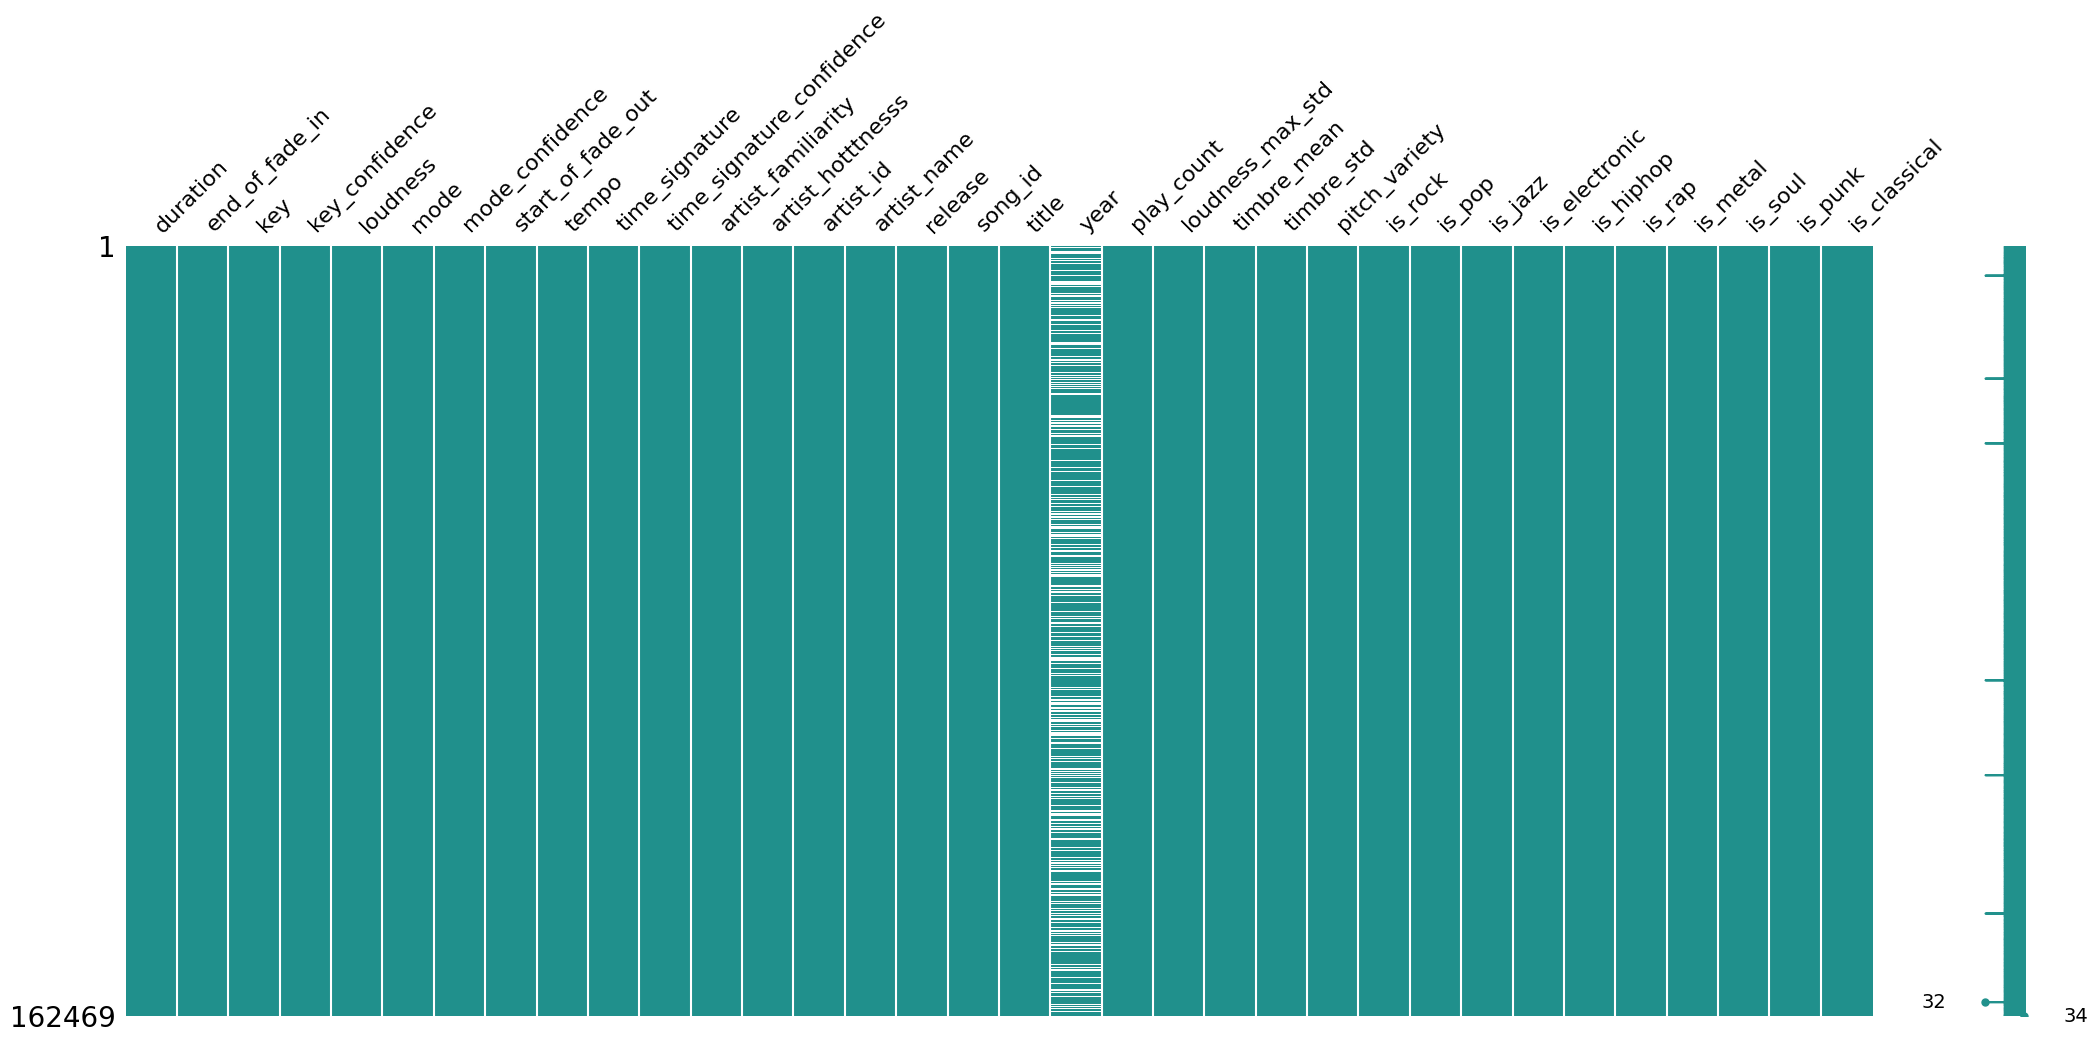

In [4]:
import missingno as msno
import matplotlib.cm as cm

# pobieramy kolor ze środka palety viridis (0.5)
# 0.0 = ciemny fiolet, 1.0 = żółty.
color_viridis = cm.viridis(0.5)

msno.matrix(df, color = cm.viridis(0.5)[:3]) #potrzebne RBG a nie RGBA

<Axes: >

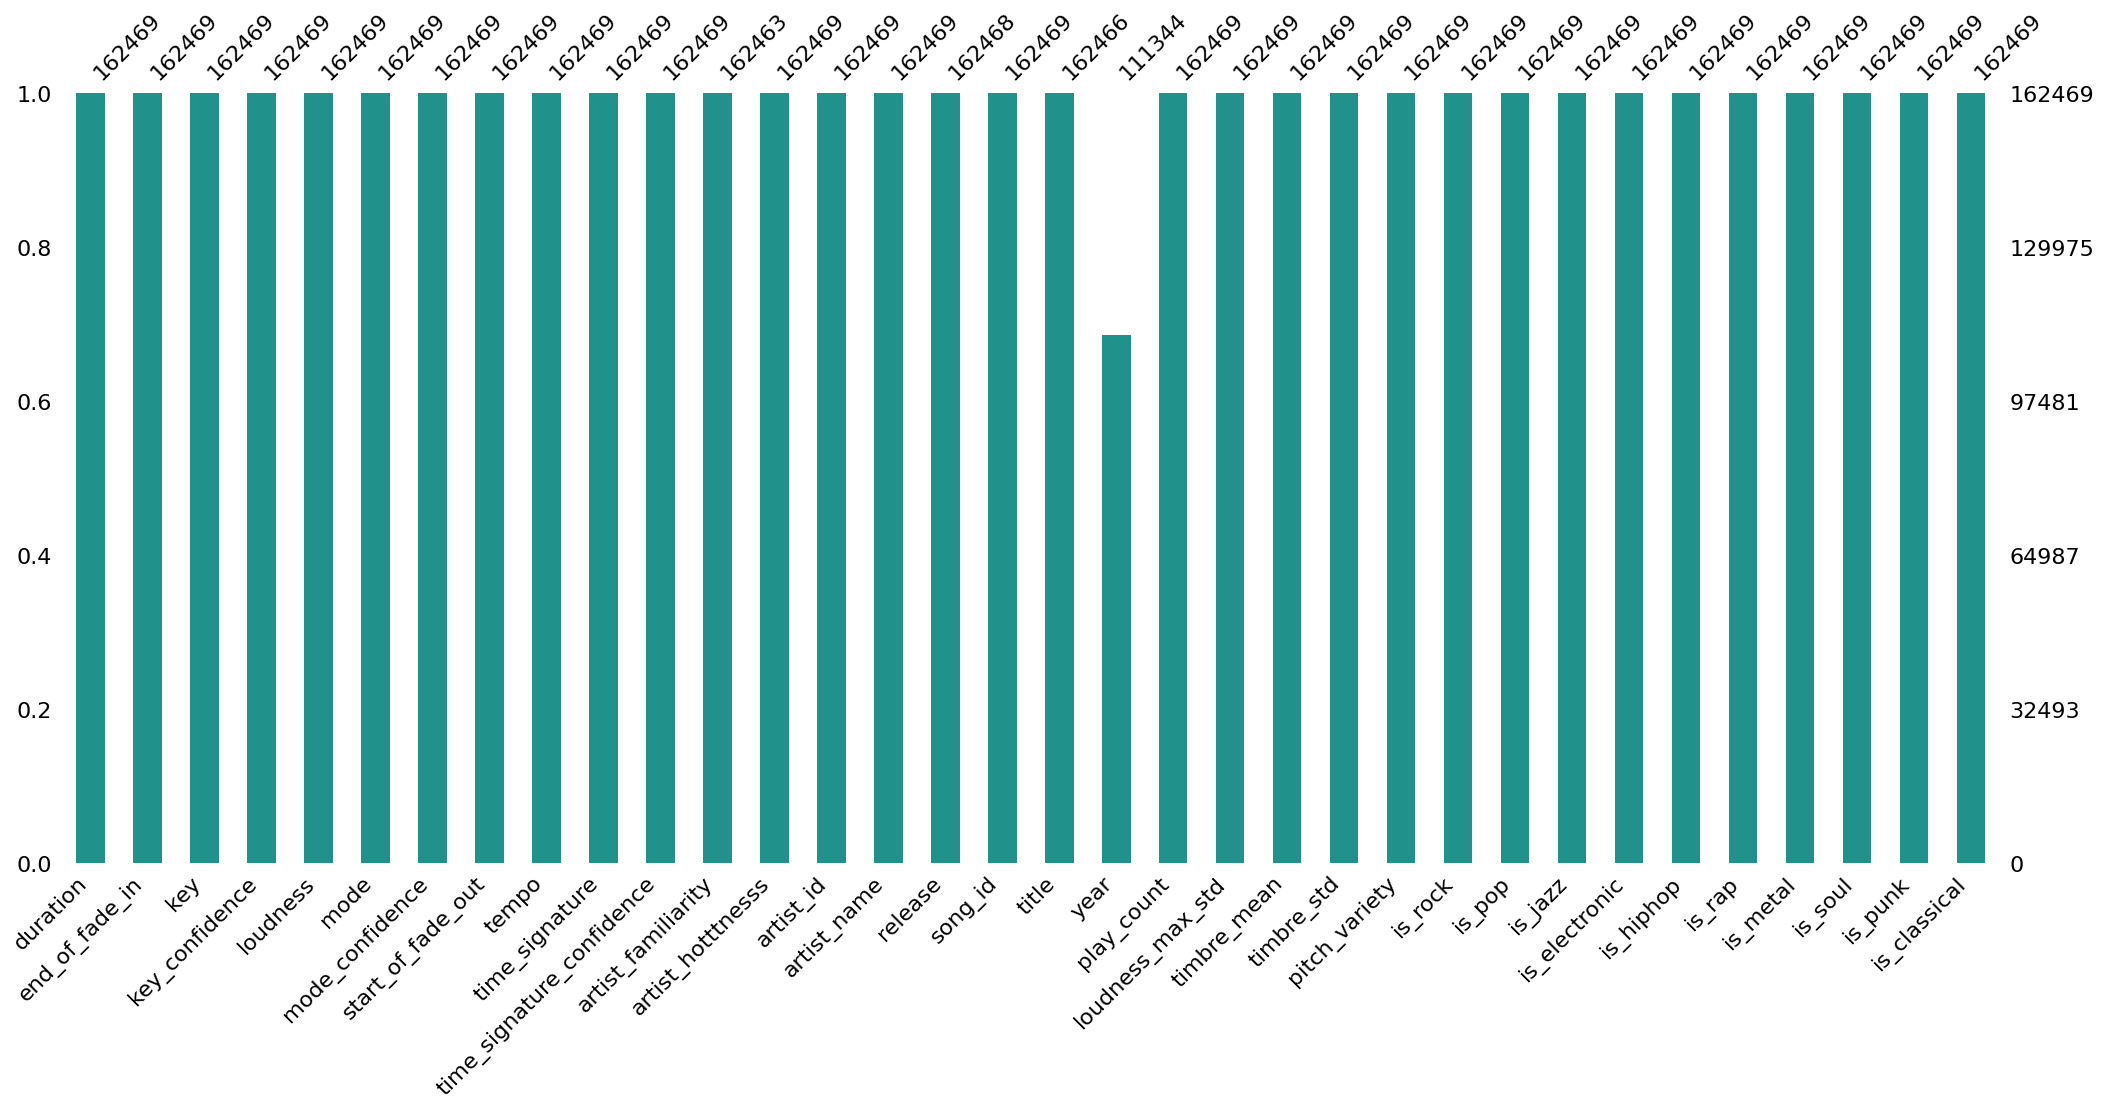

In [5]:
msno.bar(df, color=cm.viridis(0.5))

### NaN-handling

Sprawdzamy wartości NaN pozostałe po wcześniejszym preprocessingu

In [6]:
missing_data = df.isna().sum()
print(missing_data[missing_data > 0])

artist_familiarity        6
release                   1
title                     3
year                  51125
dtype: int64


In [7]:
missing_data_prc = df.isna().mean() * 100
print(missing_data_prc[missing_data_prc > 0])

artist_familiarity     0.003693
release                0.000616
title                  0.001847
year                  31.467542
dtype: float64


W przypadku kolumn, w którym braki są znikome (poniżej 1%) możemy od razu usunąć wybrakowane wiersze.

In [ ]:
df = df.dropna(subset=['title', 'release', 'artist_familiarity'])

In [9]:
missing_data_prc = df.isna().mean() * 100
print(missing_data_prc[missing_data_prc > 0])

year    31.46517
dtype: float64


W przypadku kolumny 'year' wartości brakujące stanowią ok. 31.5% wszystkich danych. Możemy spróbować imputować je medianą.

Sprawdzamy najpierw rozkład kolumny 'year'.

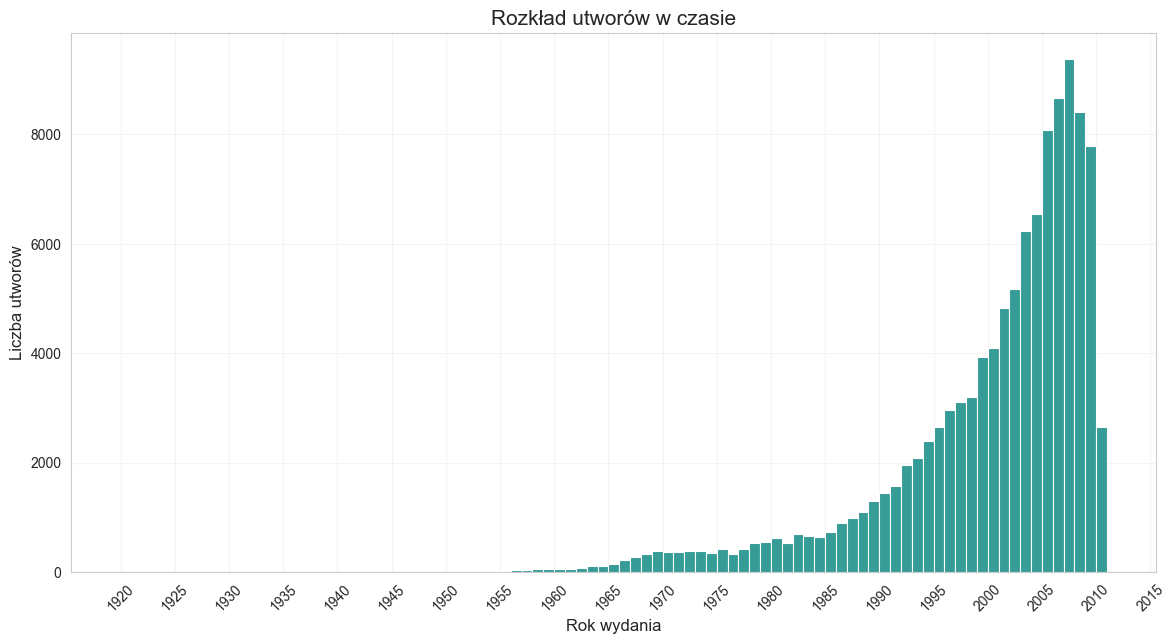

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

ax = sns.histplot(data=df, x='year', bins=range(1920, 2012), color=color_viridis, alpha=0.9)

ax.xaxis.set_major_locator(ticker.MultipleLocator(5)) # ticks co 5 lat
plt.xticks(rotation=45)
plt.xlabel('Rok wydania', fontsize=12)
plt.ylabel('Liczba utworów', fontsize=12)
plt.title('Rozkład utworów w czasie', fontsize=15)
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

Możemy zauważyć mocne lewostronne skrzywienie rozkładu.

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


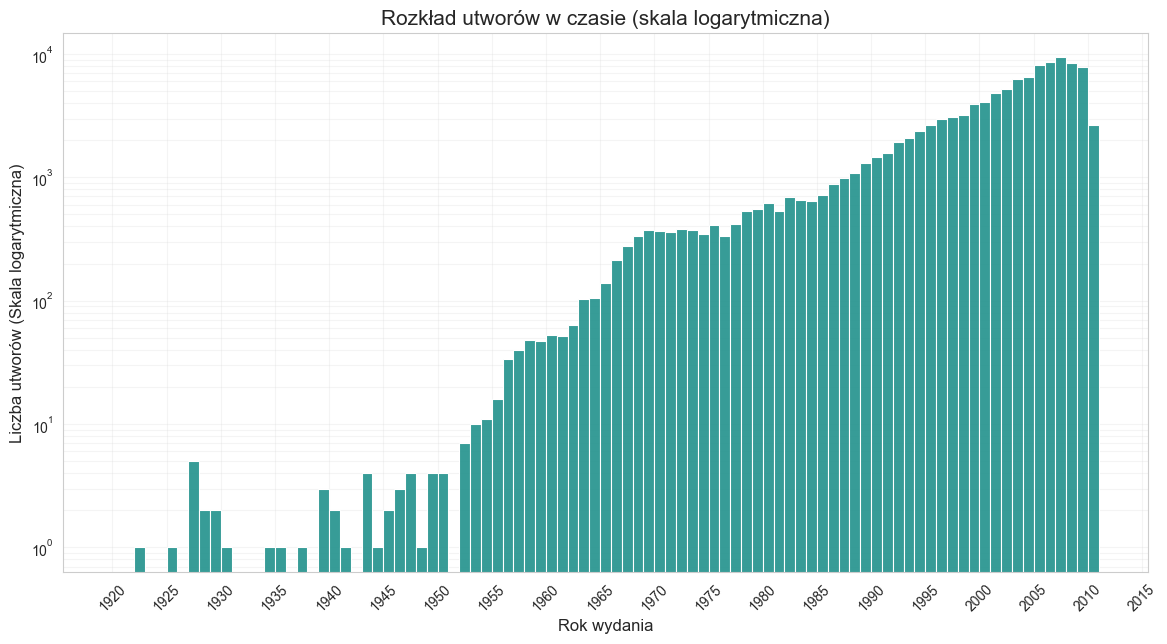

In [11]:
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

ax = sns.histplot(data=df, x='year', bins=range(1920, 2012), color=color_viridis, alpha=0.9)

ax.set_yscale('log')
plt.ylabel('Liczba utworów (Skala logarytmiczna)', fontsize=12)

ax.xaxis.set_major_locator(ticker.MultipleLocator(5)) 
plt.xticks(rotation=45) 
plt.xlabel('Rok wydania', fontsize=12)

plt.title('Rozkład utworów w czasie (skala logarytmiczna)', fontsize=15)

plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

Po zastosowaniu skali logarytmicznej, widzimy, że w zestawie występują pojedyncze utwory z lat 1920-1950, oraz rosnącą liczbę utworów w kolejnych latach, z największą liczbą piosenek na przełomie mileniów. 

Liczymy medianę, jednak w przypadku rozkładów skośnych, jej zastosowanie może znacznie zniekształcić dane (zwłaszcza w przypadku dużego procentu wartości pustych).

In [12]:
# calculate the median of 'year' column
median_year = df['year'].median()
print(f'Median year: {median_year}')

Median year: 2003.0


In [13]:
df_copy = df.copy()
df_copy['year'] = df_copy['year'].fillna(median_year)

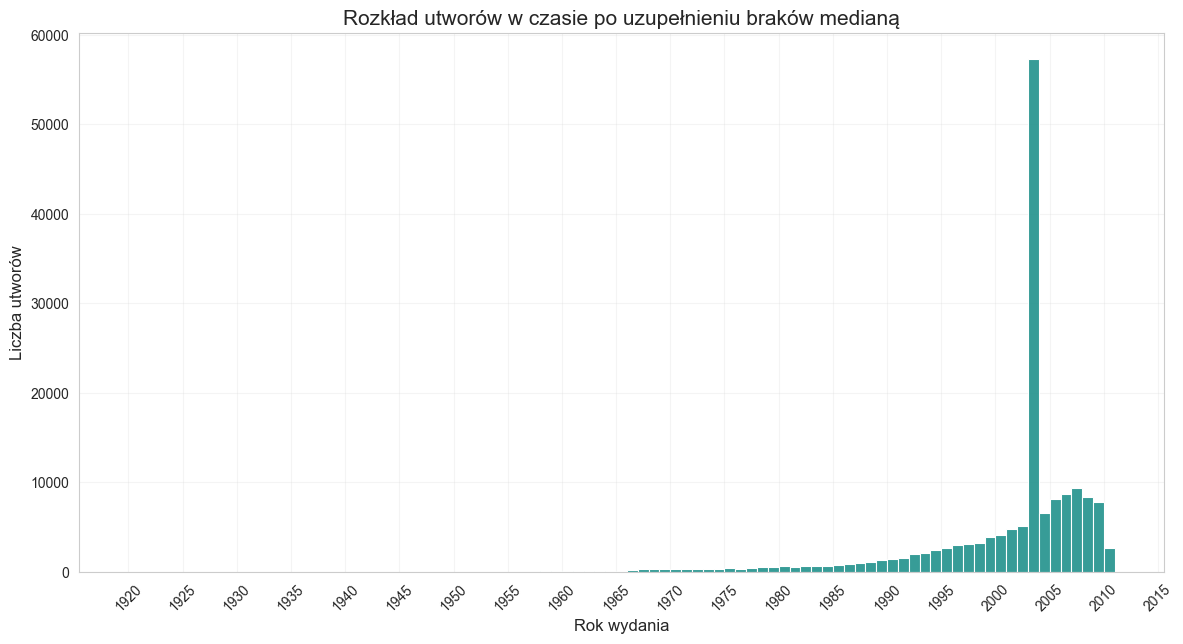

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

ax = sns.histplot(data=df_copy, x='year', bins=range(1920, 2012), color=color_viridis, alpha=0.9)

ax.xaxis.set_major_locator(ticker.MultipleLocator(5)) 
plt.xticks(rotation=45) 
plt.xlabel('Rok wydania', fontsize=12)
plt.ylabel('Liczba utworów', fontsize=12)
plt.title('Rozkład utworów w czasie po uzupełnieniu braków medianą', fontsize=15)

plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

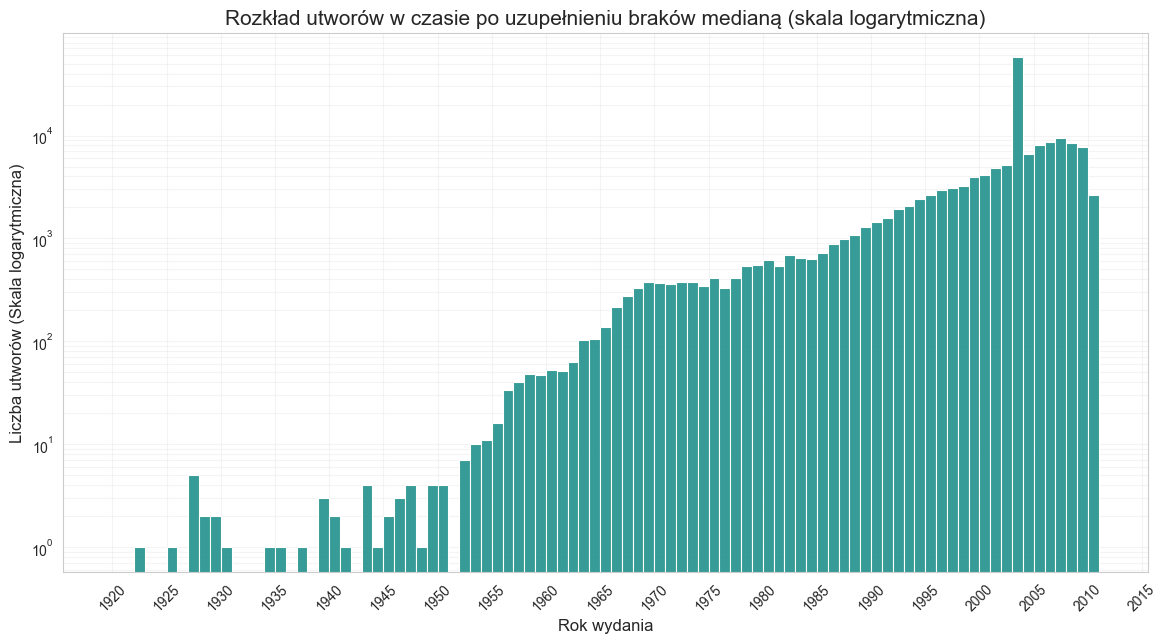

In [15]:
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

ax = sns.histplot(data=df_copy, x='year', bins=range(1920, 2012), color=color_viridis, alpha=0.9)

ax.set_yscale('log')
plt.ylabel('Liczba utworów (Skala logarytmiczna)', fontsize=12)

ax.xaxis.set_major_locator(ticker.MultipleLocator(5)) 
plt.xticks(rotation=45) 
plt.xlabel('Rok wydania', fontsize=12)

plt.title('Rozkład utworów w czasie po uzupełnieniu braków medianą (skala logarytmiczna)', fontsize=15)

plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

In [16]:
len(df_copy[df_copy['year'] == 2003])

57350

Mimo że zastosowanie mediany jest zazwyczaj dobrym sposobem na uzupełnienie wartości brakujących dla rozkładów skośnych, w przypadku braków rzędu 30%, proces ten znacznie zniekształcił rozkład zmiennej, co może wpłynąć na późniejsze złe trenowanie modelu.

In [17]:
len(df)
missing_years = df['year'].isna().sum()
print(f'Total records: {len(df)}')
print(f'Missing years: {missing_years}')
print(f'Number of records after droping missing years: {len(df) - missing_years}')

Total records: 162459
Missing years: 51118
Number of records after droping missing years: 111341


Dataset na którym pracujemy, jest relatywnie duży. Po usunięciu ponad 30% danych, wciąż zostaniemy z ponad 111 tysiącami wartości, co jest wystarczające do odpowiedniego wytrenowania modeli i wyciągnięcia wniosków z eksperymentów. Usuniemy więc te wartości z datasetu.

In [18]:
df.dropna(subset=['year'], inplace=True)
len(df)

111341

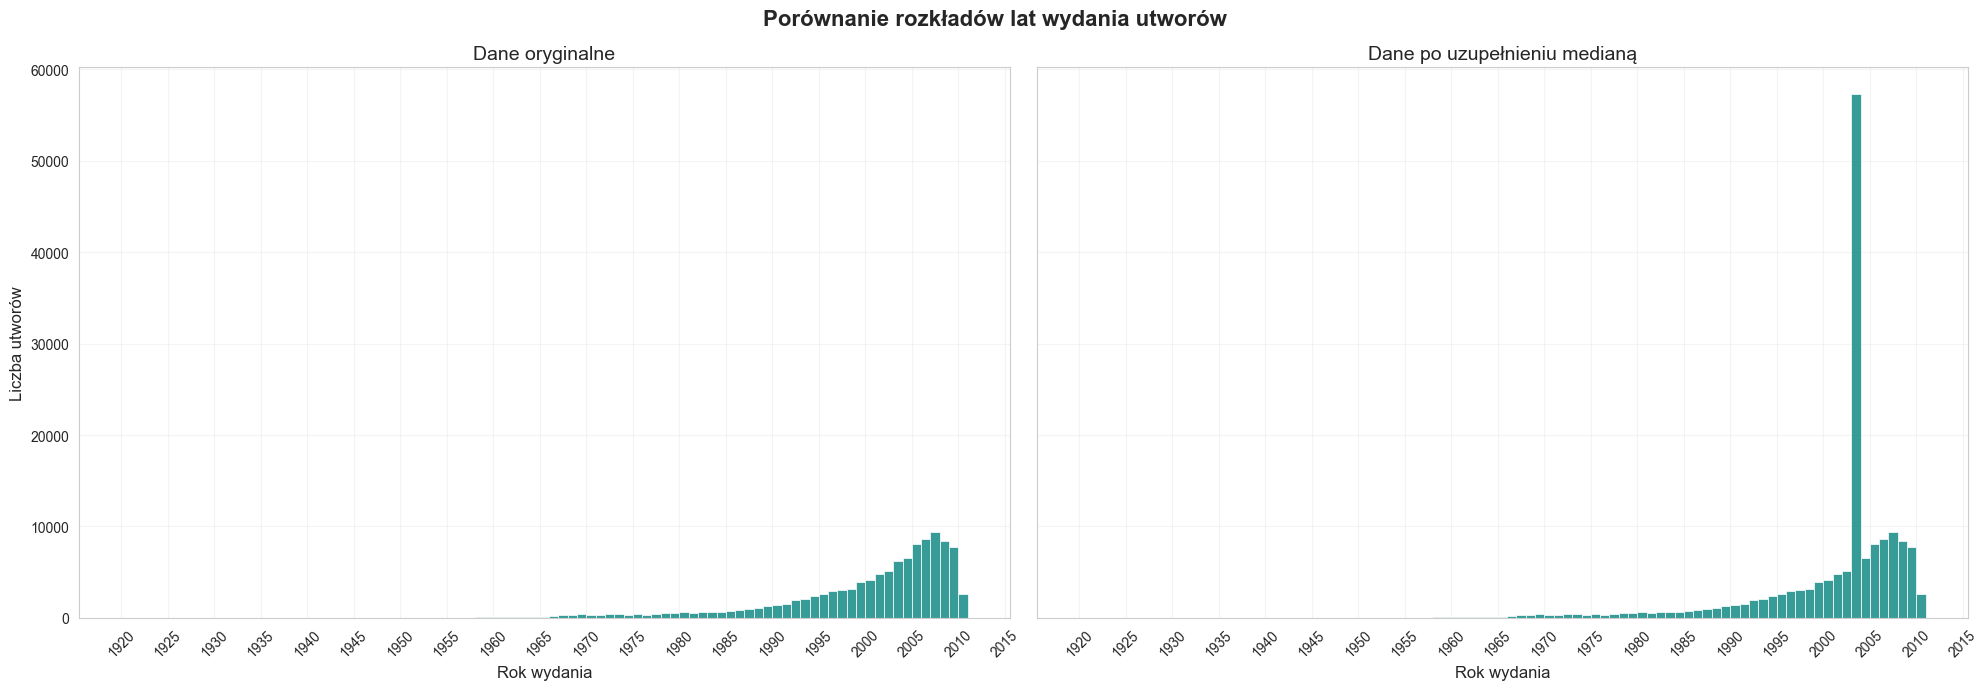

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Ustawienia ogólne
sns.set_style("whitegrid")

# Tworzymy ramkę z 1 wierszem i 2 kolumnami
# sharey=True sprawi, że oś Y będzie taka sama dla obu (łatwiej porównać skalę wzrostu słupków)
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True) 

# --- Wykres 1: Oryginał (lewy) ---
sns.histplot(data=df, x='year', bins=range(1920, 2012), 
             color=color_viridis, alpha=0.9, ax=axes[0])
axes[0].set_title('Dane oryginalne', fontsize=14)

# --- Wykres 2: Po uzupełnieniu (prawy) ---
sns.histplot(data=df_copy, x='year', bins=range(1920, 2012), 
             color=color_viridis, alpha=0.9, ax=axes[1])
axes[1].set_title('Dane po uzupełnieniu medianą', fontsize=14)

# --- Wspólne formatowanie dla obu wykresów ---
for ax in axes:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5)) # Ticki co 5 lat
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('Rok wydania', fontsize=12)
    ax.set_ylabel('Liczba utworów', fontsize=12)
    ax.grid(True, which="both", ls="-", alpha=0.2)

plt.suptitle('Porównanie rozkładów lat wydania utworów', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

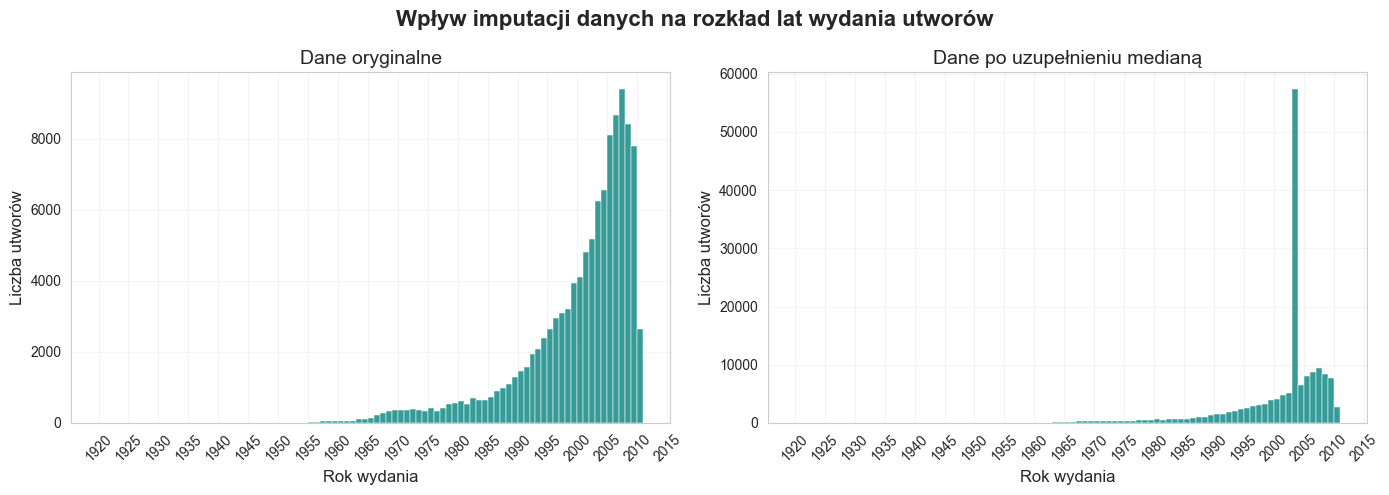

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Ustawienia ogólne
sns.set_style("whitegrid")

# Tworzymy ramkę z 1 wierszem i 2 kolumnami
# sharey=True sprawi, że oś Y będzie taka sama dla obu (łatwiej porównać skalę wzrostu słupków)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False) 

# --- Wykres 1: Oryginał (lewy) ---
sns.histplot(data=df, x='year', bins=range(1920, 2012), 
             color=color_viridis, alpha=0.9, ax=axes[0])
axes[0].set_title('Dane oryginalne', fontsize=14)

# --- Wykres 2: Po uzupełnieniu (prawy) ---
sns.histplot(data=df_copy, x='year', bins=range(1920, 2012), 
             color=color_viridis, alpha=0.9, ax=axes[1])
axes[1].set_title('Dane po uzupełnieniu medianą', fontsize=14)

# --- Wspólne formatowanie dla obu wykresów ---
for ax in axes:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5)) # Ticki co 5 lat
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('Rok wydania', fontsize=12)
    ax.set_ylabel('Liczba utworów', fontsize=12)
    ax.grid(True, which="both", ls="-", alpha=0.2)

plt.suptitle('Wpływ imputacji danych na rozkład lat wydania utworów', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Wiek utworu

In [21]:
REFERENCE_YEAR = 2011  # rok stworzenia Million Song Dataset
#df = df.copy()

# wymuszenie typu liczbowego 
df['year'] = pd.to_numeric(df['year'], errors='coerce')
#
#  obliczenie wieku utworu w roku 2011
df['song_age'] = REFERENCE_YEAR - df['year']

# zastosowanie falg dla poszcególnych dekad
df['is_older_than_50s'] = (df['year'] < 1950).astype(int)
df['is_50s'] = ((df['year'] >= 1950) & (df['year'] < 1960)).astype(int)
df['is_60s'] = ((df['year'] >= 1960) & (df['year'] < 1970)).astype(int)
df['is_70s'] = ((df['year'] >= 1970) & (df['year'] < 1980)).astype(int)
df['is_80s'] = ((df['year'] >= 1980) & (df['year'] < 1990)).astype(int)
df['is_90s'] = ((df['year'] >= 1990) & (df['year'] < 2000)).astype(int)
df['is_00s'] = ((df['year'] >= 2000) & (df['year'] < 2011)).astype(int)

In [22]:
# convert year to integer
df['year'] = df['year'].astype(int)
df['song_age'] = df['song_age'].astype(int)

In [23]:
pd.set_option('display.max_columns', None)
df.sample()

,duration,end_of_fade_in,key,key_confidence,loudness,mode,mode_confidence,start_of_fade_out,tempo,time_signature,time_signature_confidence,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,song_age,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s
143735,75.59791,0.0,2,0.741,-3.172,1,0.629,72.046,131.893,1,0.0,0.641186,0.434128,ARH65201187B9B958F,Frog Eyes,Ego Scriptor,SONQTFQ12A8C13F425,I Like Dot Dot Dot,2004,54,2.595511,11.606723,31.910578,0.683321,1,1,0,0,0,0,0,0,1,0,7,0,0,0,0,0,0,1


### one-hot-encoding kolumn 'key' i 'time_signature'

#### key

Na początek mapujmey liczby (1-11) na poszczególne tonacje (C, C#, etc.)

In [24]:
key_mapping = {
    0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F',
    6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'
}
df['key'] = df['key'].map(key_mapping)
df.sample()

,duration,end_of_fade_in,key,key_confidence,loudness,mode,mode_confidence,start_of_fade_out,tempo,time_signature,time_signature_confidence,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,song_age,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s
69517,258.06322,0.267,B,0.063,-8.208,0,0.321,249.017,123.484,4,0.0,0.752319,0.540158,ARROQSO1187B9AEB80,Talking Heads,Talking Heads 77 [w/Bonus Tracks & Interactive...,SOCZDGH12A6D4FAABA,Psycho Killer (Acoustic),2005,7247,5.627145,6.191461,31.518408,0.790351,1,1,1,1,0,0,1,0,1,0,6,0,0,0,0,0,0,1


Następnie wykonujemy one-hot-encoding

In [25]:
df = pd.get_dummies(df, columns=['key'], prefix='key', drop_first=True)

In [26]:
df.sample()

,duration,end_of_fade_in,key_confidence,loudness,mode,mode_confidence,start_of_fade_out,tempo,time_signature,time_signature_confidence,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,song_age,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#
150924,163.60444,0.0,0.341,-5.593,1,0.366,163.604,156.297,4,0.925,0.627841,0.465579,AR9TAKL1187B998B56,Radio 4,Electrify,SOQEFNE12A6D4F7F0E,Sink So Low,2001,3,2.849789,3.511228,34.144668,0.890848,1,1,1,1,1,1,0,0,1,0,10,0,0,0,0,0,0,1,False,False,False,False,False,False,False,False,False,True,False


Zapomniałam podać typ danych jako parametr - szybka naprawa

In [27]:
key_cols = [col for col in df.columns if col.startswith('key_')]
df[key_cols] = df[key_cols].astype(int)
df.sample()


,duration,end_of_fade_in,key_confidence,loudness,mode,mode_confidence,start_of_fade_out,tempo,time_signature,time_signature_confidence,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,song_age,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#
95986,302.00118,0.0,0,-10.654,0,0.345,294.655,130.405,4,0.906,0.538207,0.404509,AR235HJ1187FB3D6E5,Klubbheads,Pump Up The Jam,SOZJGUZ12AB0182C92,Klubbhopping,1996,20,5.441093,12.383342,46.652254,1.041145,1,1,1,1,1,1,0,0,0,0,15,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1


#### time signature

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1828853658.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='time_signature', data=df, palette='viridis')


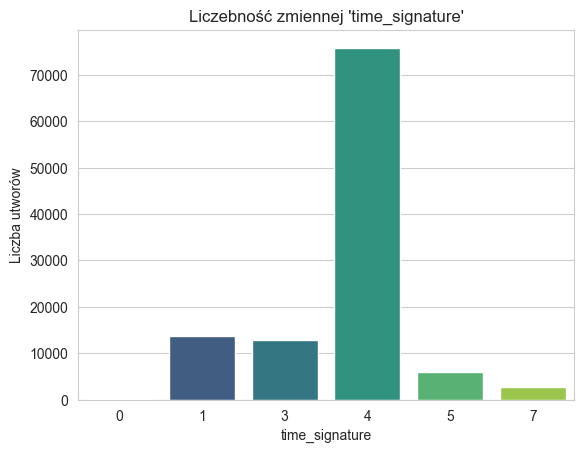

In [28]:
plt.figure()
sns.countplot(x='time_signature', data=df, palette='viridis')
plt.title('Liczebność zmiennej \'time_signature\'')
plt.ylabel('Liczba utworów')
plt.show()

uwaga: nie wszystkie metra występują w danych

In [29]:
df = pd.get_dummies(df, columns=['time_signature'], prefix='ts', drop_first=True, dtype=int)
df.sample()

,duration,end_of_fade_in,key_confidence,loudness,mode,mode_confidence,start_of_fade_out,tempo,time_signature_confidence,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,song_age,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7
125711,216.18893,0.461,0,-8.34,0,0.473,208.097,115.152,1.0,0.371318,0.273952,ARIK4UA1187B9AD6B1,Michael Pinnella,Enter By The Twelfth Gate,SOQNNBT12AB0187B77,Live For The Day,2004,25,3.856327,10.08614,31.279318,0.904627,1,0,0,0,0,0,1,0,0,1,7,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0


### Rozkłady poszczególnych zmiennych w zestawie danych

In [30]:
feature_cols = df.columns.drop(['song_id', 'title', 'artist_name', 'release'])
feature_cols 

Index(['duration', 'end_of_fade_in', 'key_confidence', 'loudness', 'mode',
       'mode_confidence', 'start_of_fade_out', 'tempo',
       'time_signature_confidence', 'artist_familiarity', 'artist_hotttnesss',
       'artist_id', 'year', 'play_count', 'loudness_max_std', 'timbre_mean',
       'timbre_std', 'pitch_variety', 'is_rock', 'is_pop', 'is_jazz',
       'is_electronic', 'is_hiphop', 'is_rap', 'is_metal', 'is_soul',
       'is_punk', 'is_classical', 'song_age', 'is_older_than_50s', 'is_50s',
       'is_60s', 'is_70s', 'is_80s', 'is_90s', 'is_00s', 'key_A#', 'key_B',
       'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#',
       'key_G', 'key_G#', 'ts_1', 'ts_3', 'ts_4', 'ts_5', 'ts_7'],
      dtype='object')

#### Zmienne kategoryczne

##### styl muzyczny - is_rock, is_pop, etc.

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1435312779.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')


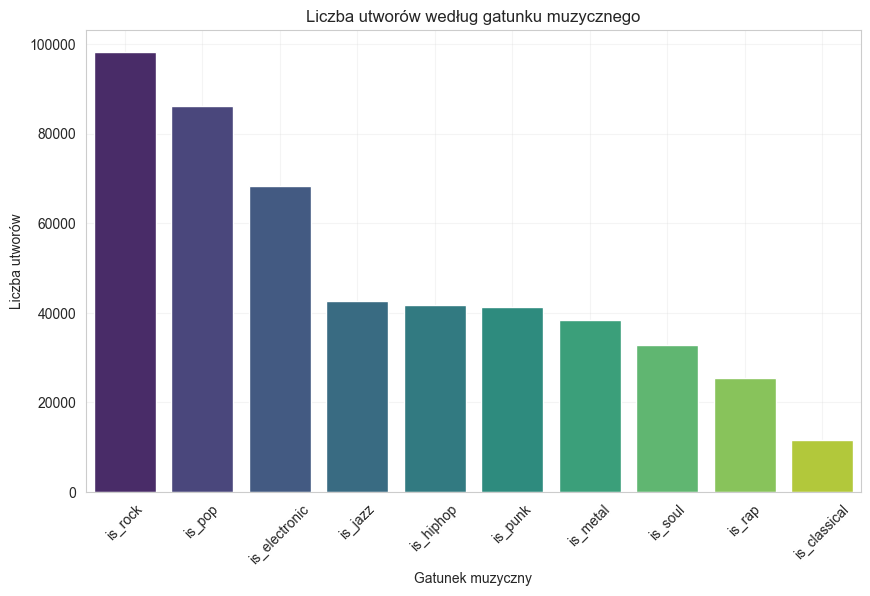

In [31]:
# plot distribution 
genre_cols = ['is_rock', 'is_pop', 'is_jazz', 'is_electronic', 'is_hiphop', 'is_rap',
       'is_metal', 'is_soul', 'is_punk', 'is_classical']
genre_counts = df[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.xlabel('Gatunek muzyczny')  
plt.ylabel('Liczba utworów')
plt.title('Liczba utworów według gatunku muzycznego')
plt.xticks(rotation=45)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

Skala logarytmiczna

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1597163863.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')


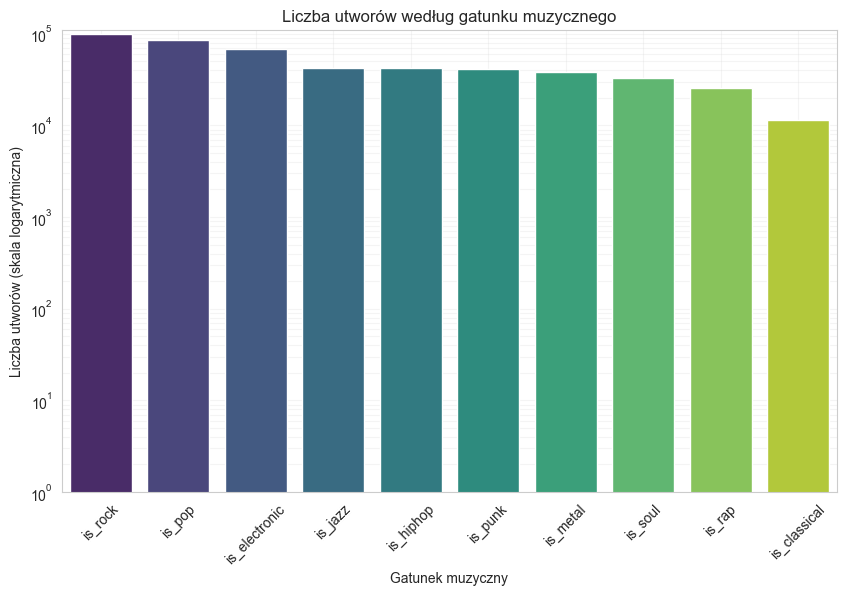

In [32]:
# plot distribution 
genre_cols = ['is_rock', 'is_pop', 'is_jazz', 'is_electronic', 'is_hiphop', 'is_rap',
       'is_metal', 'is_soul', 'is_punk', 'is_classical']
genre_counts = df[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.xlabel('Gatunek muzyczny')  
plt.yscale('log')
plt.ylim(bottom=1)
plt.ylabel('Liczba utworów (skala logarytmiczna)')
plt.title('Liczba utworów według gatunku muzycznego')
plt.xticks(rotation=45)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

##### dekady muzyczne - is_80, is_00, etc.

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1993454631.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='viridis')


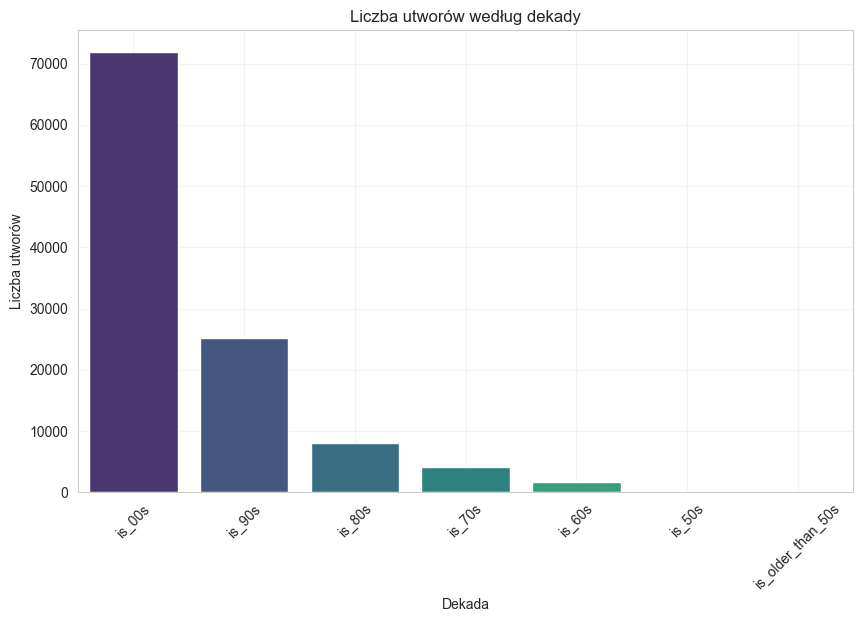

In [33]:
# plot distribution 
decade_cols = ['is_older_than_50s', 'is_50s', 'is_60s', 'is_70s', 'is_80s', 'is_90s','is_00s']
decade_counts = df[decade_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='viridis')
plt.xlabel('Dekada')  
plt.ylabel('Liczba utworów')
plt.title('Liczba utworów według dekady')
plt.xticks(rotation=45)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

Skala logarytmiczna

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1549643282.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='viridis')


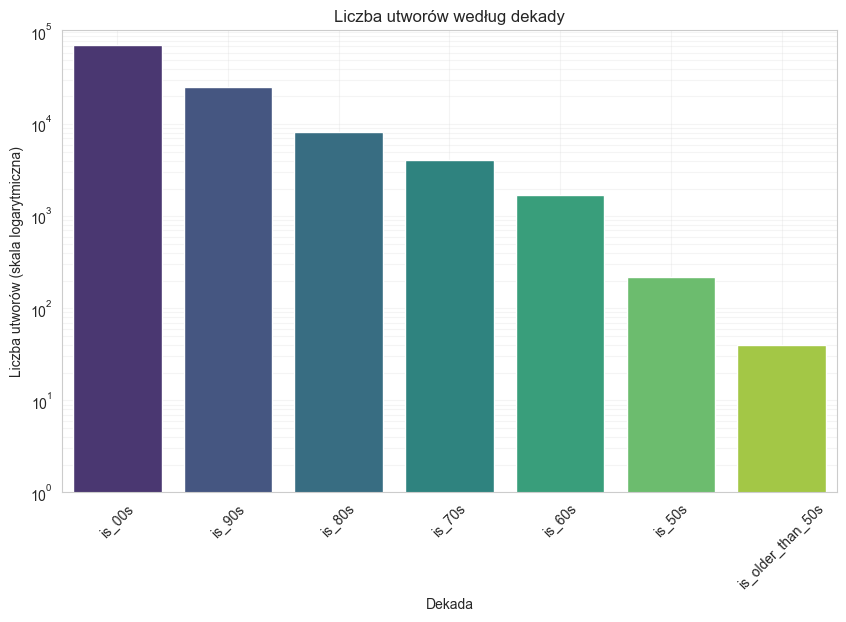

In [34]:
# plot distribution 
decade_cols = ['is_older_than_50s', 'is_50s', 'is_60s', 'is_70s', 'is_80s', 'is_90s','is_00s']
decade_counts = df[decade_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='viridis')
plt.xlabel('Dekada')  
plt.yscale('log')
plt.ylim(bottom=1)
plt.ylabel('Liczba utworów (skala logarytmiczna)')
plt.title('Liczba utworów według dekady')
plt.xticks(rotation=45)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

WYKRES dekada+gatunek

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\2611689241.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis', ax=axes[0])
C:\Users\48726\AppData\Local\Temp\ipykernel_39132\2611689241.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(clean_genre_labels, rotation=0)
C:\Users\48726\AppData\Local\Temp\ipykernel_39132\2611689241.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='viridis', ax=axes[1])
C:\Users\48726\AppData\Local\Temp\ipykernel_39132\2611689241.p

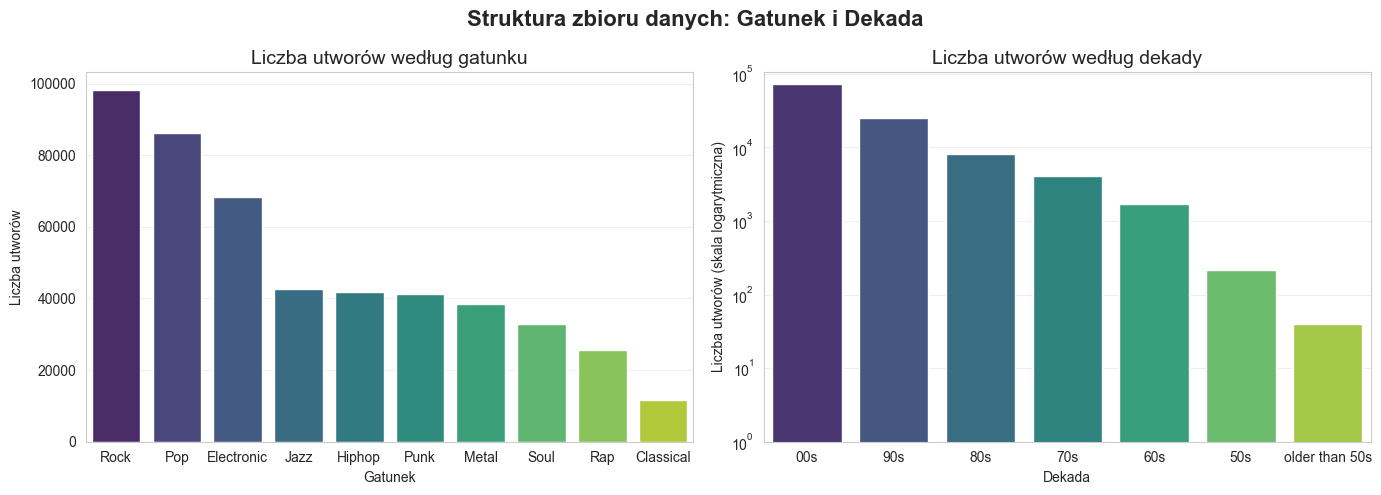

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# agreagacja danych
genre_cols = ['is_rock', 'is_pop', 'is_jazz', 'is_electronic', 'is_hiphop', 'is_rap',
       'is_metal', 'is_soul', 'is_punk', 'is_classical']
genre_counts = df[genre_cols].sum().sort_values(ascending=False)

decade_cols = ['is_older_than_50s', 'is_50s', 'is_60s', 'is_70s', 'is_80s', 'is_90s','is_00s']
decade_counts = df[decade_cols].sum().sort_values(ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis', ax=axes[0])
axes[0].set_title('Liczba utworów według gatunku', fontsize=14)
axes[0].set_ylabel('Liczba utworów')
axes[0].set_xlabel('Gatunek')

# czyszczenie etykiet 
clean_genre_labels = [label.replace('is_', '').capitalize() for label in genre_counts.index]
axes[0].set_xticklabels(clean_genre_labels, rotation=0)
axes[0].grid(True, axis='y', alpha=0.3)

sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='viridis', ax=axes[1])
axes[1].set_title('Liczba utworów według dekady', fontsize=14)
axes[1].set_ylabel('Liczba utworów (skala logarytmiczna)')
axes[1].set_xlabel('Dekada')
axes[1].set_yscale('log')
axes[1].set_ylim(bottom=1)

# czyszczenie etykiet 
clean_decade_labels = [label.replace('is_', '').replace('_', ' ') for label in decade_counts.index]
axes[1].set_xticklabels(clean_decade_labels, rotation=0)
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Struktura zbioru danych: Gatunek i Dekada', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##### tonacja (zmienna 'key')

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\2601029668.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=key_counts.index, y=key_counts.values, palette='viridis')


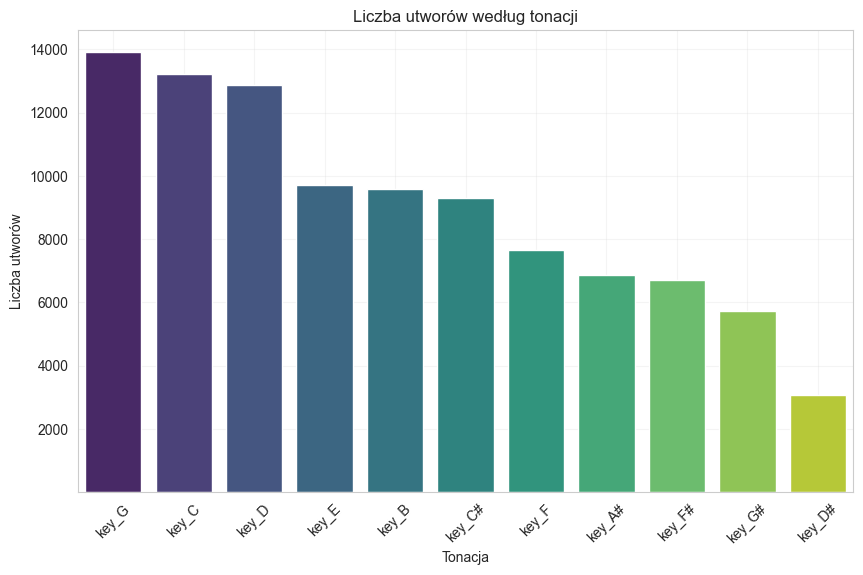

In [36]:
# plot distribution 
key_cols = ['key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#','key_G', 'key_G#']
key_counts = df[key_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=key_counts.index, y=key_counts.values, palette='viridis')
plt.xlabel('Tonacja')  
plt.ylim(bottom=1)
plt.ylabel('Liczba utworów')
plt.title('Liczba utworów według tonacji')
plt.xticks(rotation=45)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

skala logarytmiczna

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\729544640.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=key_counts.index, y=key_counts.values, palette='viridis')


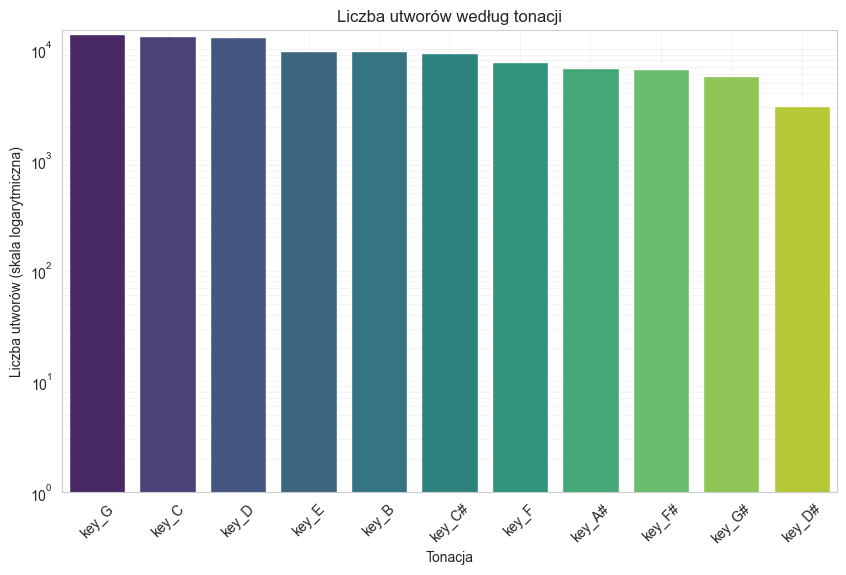

In [37]:
# plot distribution 
# key_cols zdefiniowane wcześniej
key_counts = df[key_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=key_counts.index, y=key_counts.values, palette='viridis')
plt.xlabel('Tonacja')  
plt.yscale('log')
plt.ylim(bottom=1)
plt.ylabel('Liczba utworów (skala logarytmiczna)')
plt.title('Liczba utworów według tonacji')
plt.xticks(rotation=45)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

##### metrum (time signature)

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\2304139818.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ts_counts.index, y=ts_counts.values, palette='viridis')


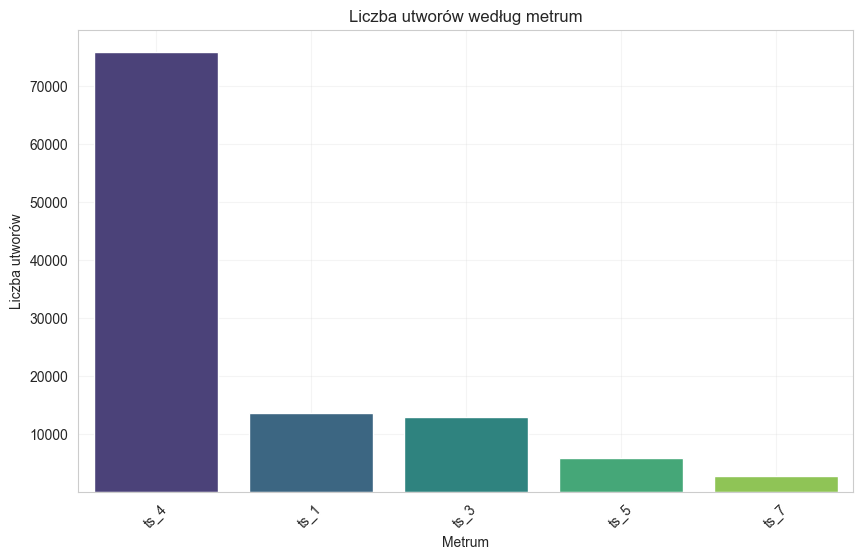

In [38]:
# plot distribution 
ts_cols = ['ts_1', 'ts_3', 'ts_4', 'ts_5', 'ts_7']
ts_counts = df[ts_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=ts_counts.index, y=ts_counts.values, palette='viridis')
plt.xlabel('Metrum')  
plt.ylim(bottom=1)
plt.ylabel('Liczba utworów')
plt.title('Liczba utworów według metrum')
plt.xticks(rotation=45)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1384226223.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ts_counts.index, y=ts_counts.values, palette='viridis')


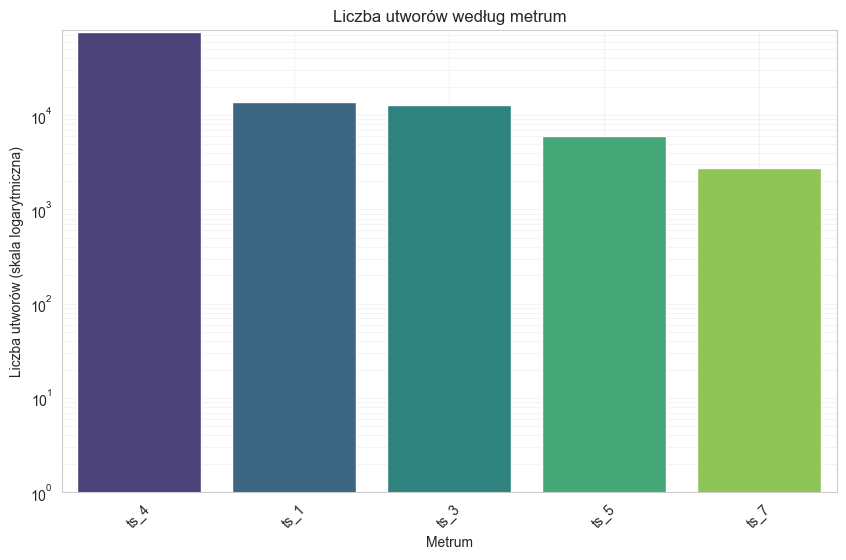

In [39]:
# plot distribution 
ts_cols = ['ts_1', 'ts_3', 'ts_4', 'ts_5', 'ts_7']
ts_counts = df[ts_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=ts_counts.index, y=ts_counts.values, palette='viridis')
plt.xlabel('Metrum')  
plt.ylim(bottom=1)
plt.yscale('log')
plt.ylabel('Liczba utworów (skala logarytmiczna)')
plt.title('Liczba utworów według metrum')
plt.xticks(rotation=45)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

##### tryb (mode)

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1840220673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='mode', data=df, palette='viridis')


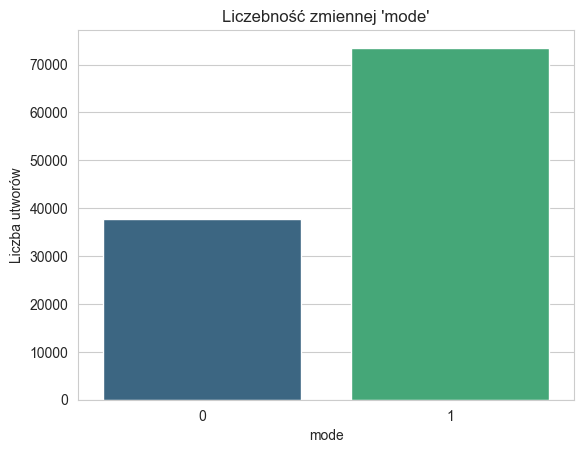

In [40]:
plt.figure()
sns.countplot(x='mode', data=df, palette='viridis')
plt.title('Liczebność zmiennej \'mode\'')
plt.ylabel('Liczba utworów')
plt.show()

WYKRES time signature + mode + key

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1826143792.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=key_counts.index, y=key_counts.values, palette='viridis', ax=axes[0])
C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1826143792.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(clean_key_labels, rotation=0)
C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1826143792.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='mode', data=df, palette='viridis', ax=axes[1])
C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1826143792.py:40: FutureWarning: 

Passing `

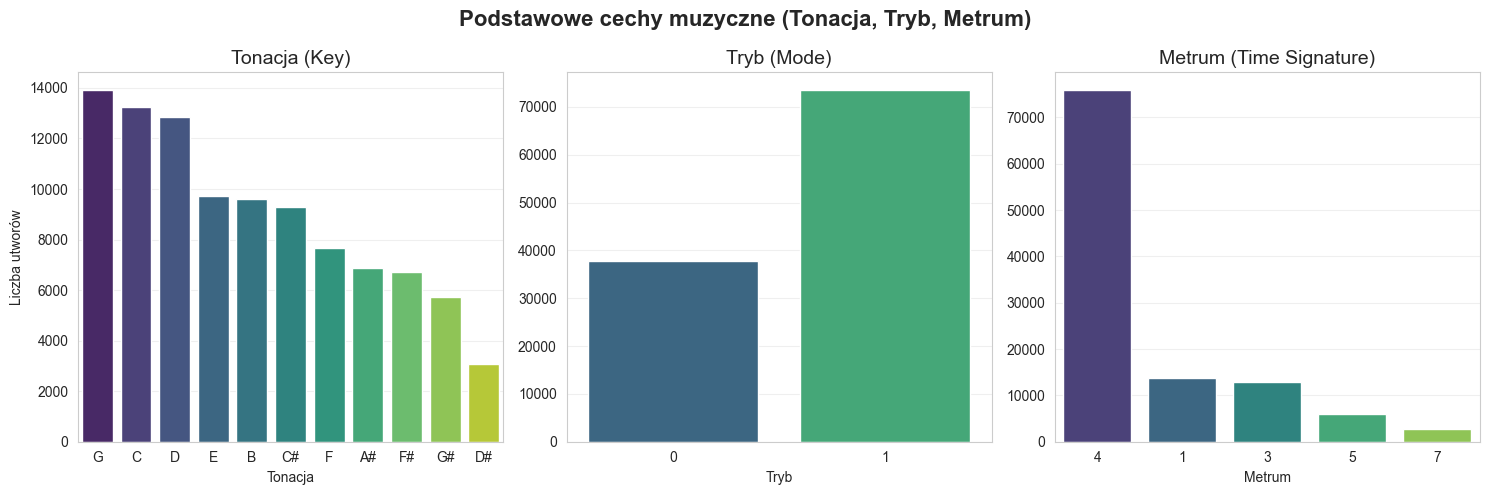

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

key_cols = ['key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#','key_G', 'key_G#']
key_counts = df[key_cols].sum().sort_values(ascending=False)

ts_cols = ['ts_1', 'ts_3', 'ts_4', 'ts_5', 'ts_7']
ts_counts = df[ts_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(x=key_counts.index, y=key_counts.values, palette='viridis', ax=axes[0])
axes[0].set_title('Tonacja (Key)', fontsize=14)
axes[0].set_ylabel('Liczba utworów')
axes[0].set_xlabel('Tonacja')

clean_key_labels = [label.replace('key_', '').replace('_', ' ') for label in key_counts.index]
axes[0].set_xticklabels(clean_key_labels, rotation=0)
axes[0].grid(True, axis='y', alpha=0.3)


sns.countplot(x='mode', data=df, palette='viridis', ax=axes[1])
axes[1].set_title('Tryb (Mode)', fontsize=14)
axes[1].set_ylabel('') # usuwamy label Y, bo jest pośrodku (opcjonalne)
axes[1].set_xlabel('Tryb')

axes[1].grid(True, axis='y', alpha=0.3)


sns.barplot(x=ts_counts.index, y=ts_counts.values, palette='viridis', ax=axes[2])
axes[2].set_title('Metrum (Time Signature)', fontsize=14)
axes[2].set_ylabel('') # usuwamy label Y
axes[2].set_xlabel('Metrum')

clean_ts_labels = [label.replace('ts_', '') for label in ts_counts.index]
axes[2].set_xticklabels(clean_ts_labels)
axes[2].grid(True, axis='y', alpha=0.3)

plt.suptitle('Podstawowe cechy muzyczne (Tonacja, Tryb, Metrum)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##### rok wydania

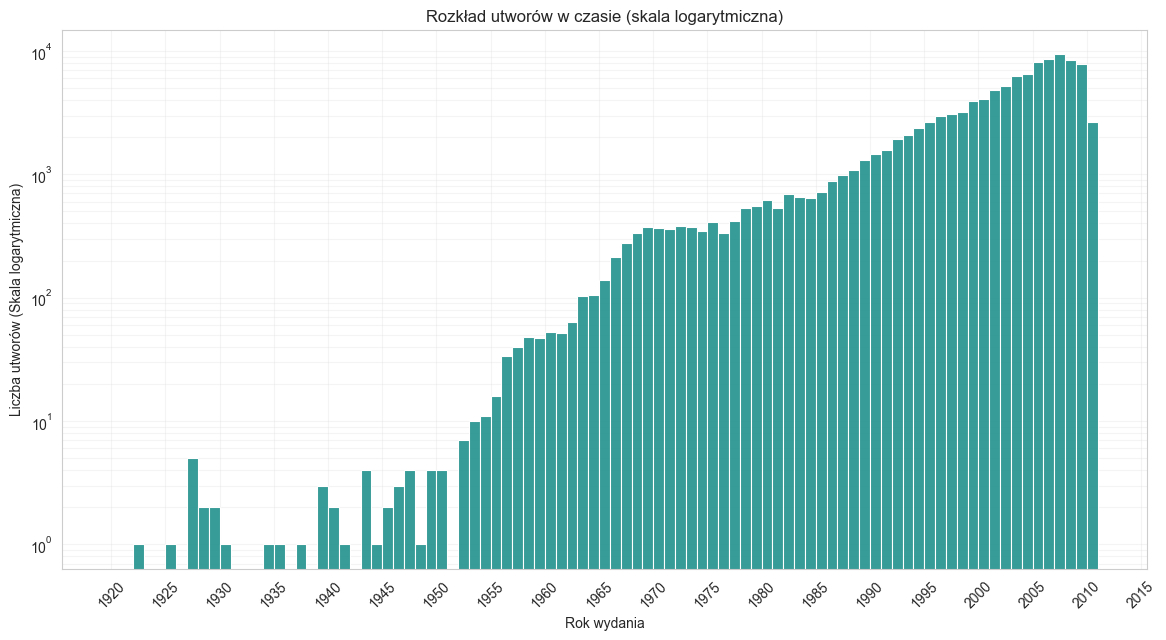

In [42]:
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

ax = sns.histplot(data=df, x='year', bins=range(1920, 2012), color=color_viridis, alpha=0.9)
#ax = sns.countplot(x='year', data=df, palette='viridis')

ax.set_yscale('log')
plt.ylabel('Liczba utworów (Skala logarytmiczna)')

ax.xaxis.set_major_locator(ticker.MultipleLocator(5)) 
plt.xticks(rotation=45)
plt.xlabel('Rok wydania')

plt.title('Rozkład utworów w czasie (skala logarytmiczna)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

#### Zmienne ciągłe 

##### Grupa 1: artist_hotttnesss + artist_popularity

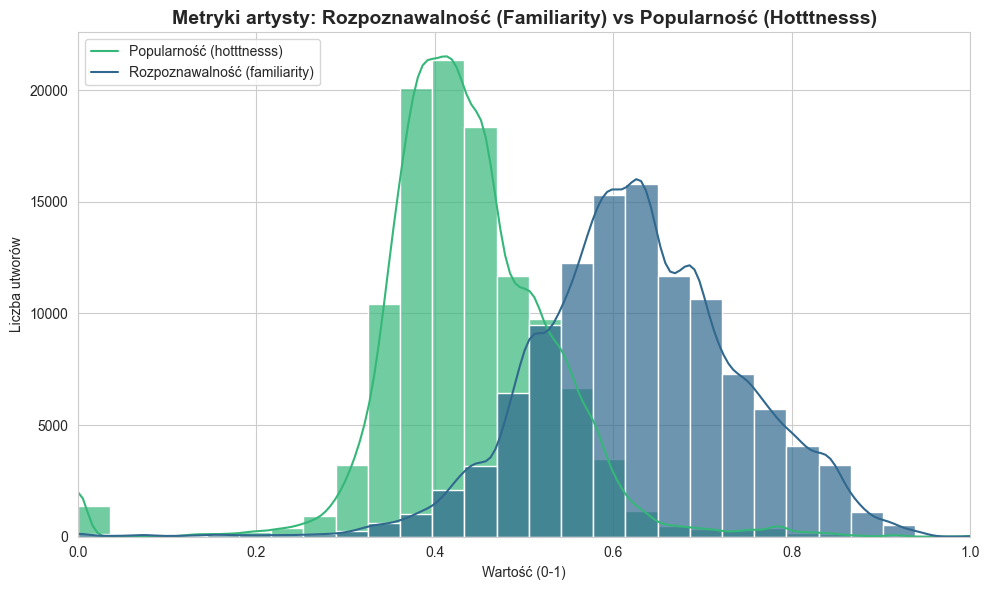

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

artist_df = df[['artist_familiarity', 'artist_hotttnesss']].copy()

artist_df.columns = ['Familiarity (Rozpoznawalność)', 'Hotttnesss (Popularność)']

# melting- zamiana z formatu szerokiego na długi (żeby Seaborn narysował dwie serie na jednym wykresie z automatyczną legendą)
artist_melted = artist_df.melt(var_name='Metryka', value_name='Wartość')

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.histplot(
    data=artist_melted, 
    bins=30,
    x='Wartość', 
    hue='Metryka',       
    kde=True,            
    #element='step',     # styl "schodkowy" 
    palette='viridis',   
    alpha=0.7            
)

plt.title('Metryki artysty: Rozpoznawalność (Familiarity) vs Popularność (Hotttnesss)', fontsize=14, fontweight='bold')
plt.xlabel('Wartość (0-1)')
plt.ylabel('Liczba utworów')
plt.xlim(0, 1) 

plt.legend(labels=['Popularność (hotttnesss)', 'Rozpoznawalność (familiarity)'], loc='upper left')

plt.tight_layout()
plt.show()

##### Grupa 2: duration + start_of_fade_out + end_of_fade_in

In [65]:
df_copy.sample()

,duration,end_of_fade_in,key,key_confidence,loudness,mode,mode_confidence,start_of_fade_out,tempo,time_signature,time_signature_confidence,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical
91158,260.80608,8.696,5,0.606,-12.464,1,0.614,249.098,160.648,4,0.125,0.838924,0.607793,AR1ABAO1187FB531E1,Alice Cooper,Special Forces,SORFHWX12A58A791BB,Who Do You Think We Are (Album Version),1981.0,171,7.661674,4.30007,29.725341,0.850725,1,1,0,0,0,0,1,0,1,0


In [134]:
viridis_colors = sns.color_palette("viridis", 5)

In [135]:
viridis_colors

[(0.267968, 0.223549, 0.512008),
 (0.190631, 0.407061, 0.556089),
 (0.127568, 0.566949, 0.550556),
 (0.20803, 0.718701, 0.472873),
 (0.565498, 0.84243, 0.262877)]

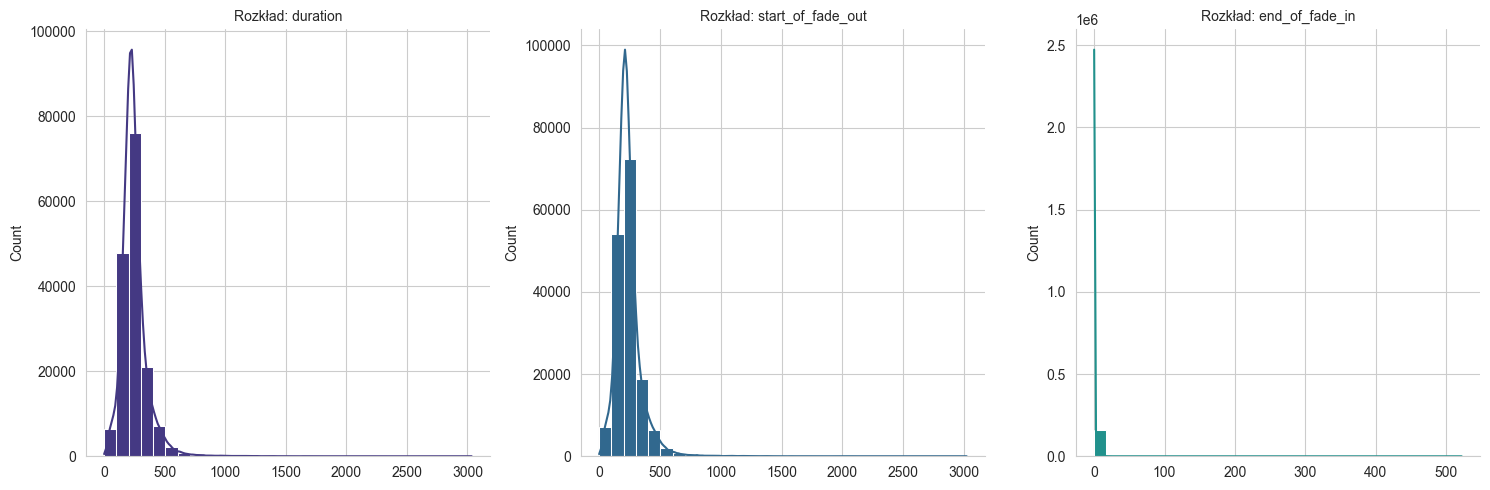

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['duration', 'start_of_fade_out', 'end_of_fade_in']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(data=df_copy, x=col, kde=True, ax=axes[i], color=viridis_colors[i], alpha=1.0, bins=30)
    
    sns.despine(ax=axes[i])
    
    axes[i].set_title(f'Rozkład: {col}', fontsize=10)
    axes[i].set_xlabel('') 

plt.tight_layout()
plt.show()

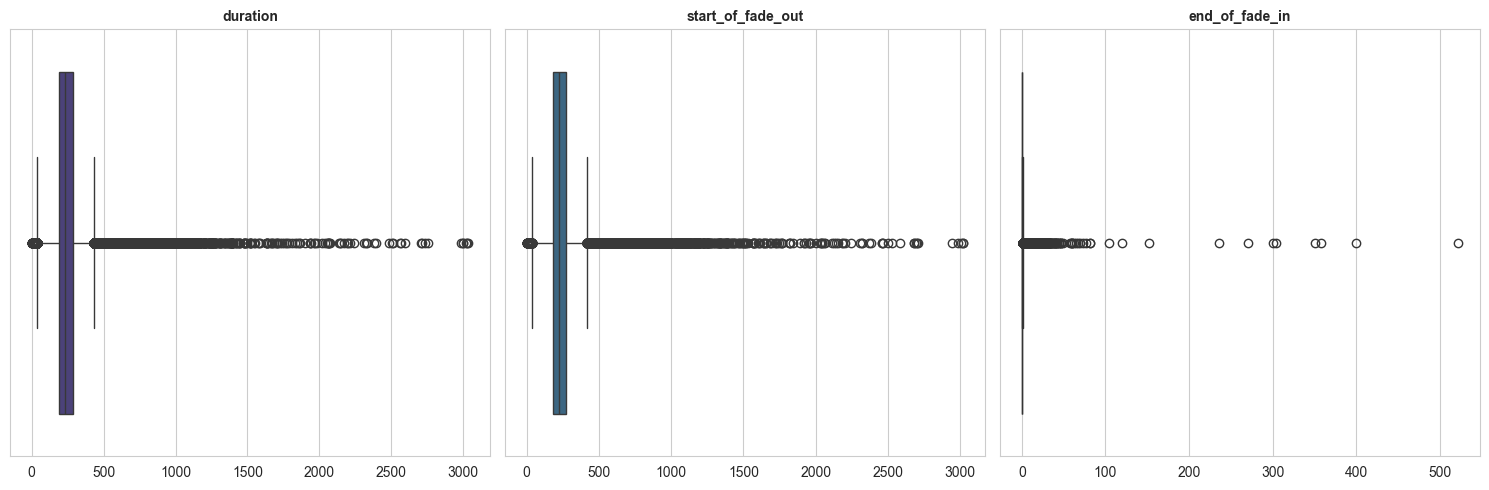

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    # rysujemy POZIOMY boxplot (orient='h', zmienna idzie na oś X)
    sns.boxplot(data=df_copy, x=col, ax=axes[i], color=viridis_colors[i], orient='h')
    
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('') # oszczędzamy miejsce w pionie
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [51]:
# show records with extreme outliers in 'duration'
outlier_duration = df[df['duration'] > 2000]
outlier_duration[['song_id', 'title', 'artist_name', 'duration']]

,song_id,title,artist_name,duration
14276,SOQTXVQ12A8C13E6C4,Chapter One: Destiny,Jean Grae,2709.23710
21011,SOICYLP12AB01832F4,I Wish Someone Had Told Me,Henry Rollins,2198.93506
24551,SOZDNJA12A8C134F94,Live From Planet X!,MF Doom,2328.11057
25103,SOMKSRX12A8C131E1E,Starless And Bible Black Sabbath,Acid Mother's Temple And The Cosmic Inferno,2069.65506
31785,SOHQNVB12A8C1416DB,Hear The Dark,Eastern Lane,2051.26485
50853,SOTQOLI12AC468B5F4,Cycle Part 2,Merzbow,2393.05098
58426,SOAWMZI12A8C13E501,dlp 3,William Basinski,2513.16200
63234,SOWPJXO12AB017F8A7,Sleeping In Traffic,Beardfish,2144.44363
76206,SOWORTS12A8C13F6A6,First Light,Shadow Gallery,2058.78812
83184,SOQZAUN12AAF3B3481,Better Than Me,China Drum,2062.47138


Wśród utworów występują wielominutowe kompozycje, które, mimo odstawania od pozostałych utworów, naprawdę przyjmują takie wartości. Najelepiej będzie więć zlogarytmować powyższe 3 zmienne i w takiej postaci przekazać je do modelu.

In [52]:
cols = ['duration', 'start_of_fade_out', 'end_of_fade_in']
df[cols].describe()

,duration,start_of_fade_out,end_of_fade_in
count,111341.000000,111341.000000,111341.000000
mean,245.796426,236.555560,0.881676
std,109.034390,106.871684,3.380477
min,0.678730,0.679000,0.000000
25%,187.088530,179.090000,0.000000
50%,231.235460,221.605000,0.192000
75%,284.185670,273.595000,0.421000
max,3024.665670,3020.301000,522.019000


In [53]:
for col in cols:
    df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
df = df.drop(columns=cols)
df.sample()

,key_confidence,loudness,mode,mode_confidence,tempo,time_signature_confidence,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,song_age,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,duration_log,start_of_fade_out_log,end_of_fade_in_log
115087,0,-15.534,1,0.255,73.116,0.548,0.837589,0.554062,ARERLPG1187FB3BB39,Tom Waits,Alice,SOOKJRW12A6D4F7964,Lost In The Harbour,2002,327,7.73821,-9.334905,44.876402,1.043743,1,1,1,0,1,0,1,1,1,1,9,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,5.421656,5.36232,1.189975


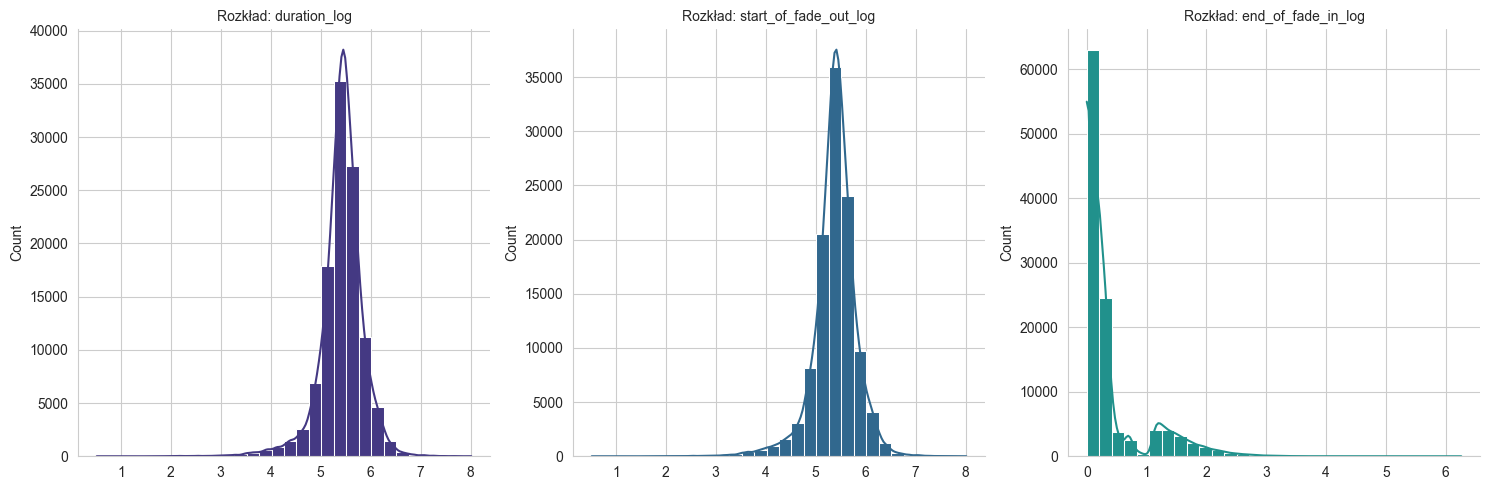

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['duration_log', 'start_of_fade_out_log', 'end_of_fade_in_log']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(data=df, bins=30, x=col, kde=True, ax=axes[i], color=viridis_colors[i], alpha=1.0)
    sns.despine(ax=axes[i])
    
    axes[i].set_title(f'Rozkład: {col}', fontsize=10)
    axes[i].set_xlabel('') # Często opis osi X jest zbędny, jeśli tytuł mówi co to

plt.tight_layout()
plt.show()

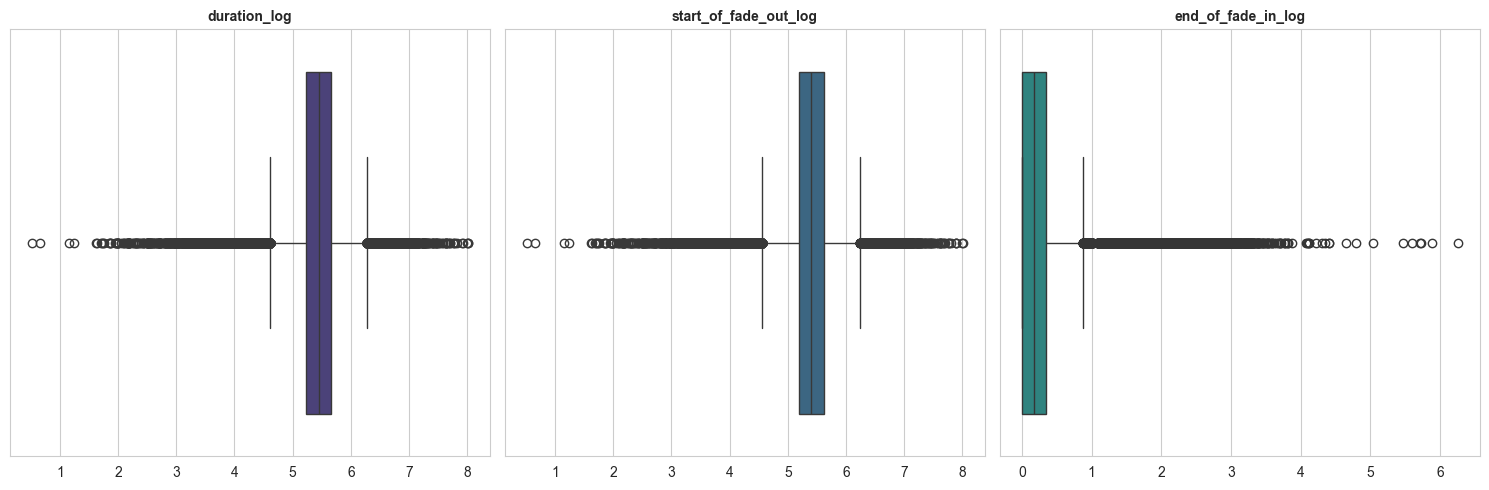

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    # rysujemy POZIOMY boxplot (orient='h', zmienna idzie na oś X)
    sns.boxplot(data=df, x=col, ax=axes[i], color=viridis_colors[i], orient='h')
    
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('') 
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Możemy zauważyć, że mimo logarytmowania, rozkład zmiennej 'end_of_fade_in' wciąż pozostaje "przyklejony" do zera. Oznacza to, że znaczna część utworów w ogóle nie ma fade-in'u, tylko od razu zaczyna się głośno. Możemy więc dodać binarną kolumnę 'has_fade_in'.

Widzimy również, że zmienne 'duration_log' oraz 'statr_of_fade_out_log' mają praktycznie takie same rozkłady, co może wskazywać na to, że większość utworów nie ma fade-out'u, tylko kończy się od razu. Dodamy również kolumnę "has_fade_out"

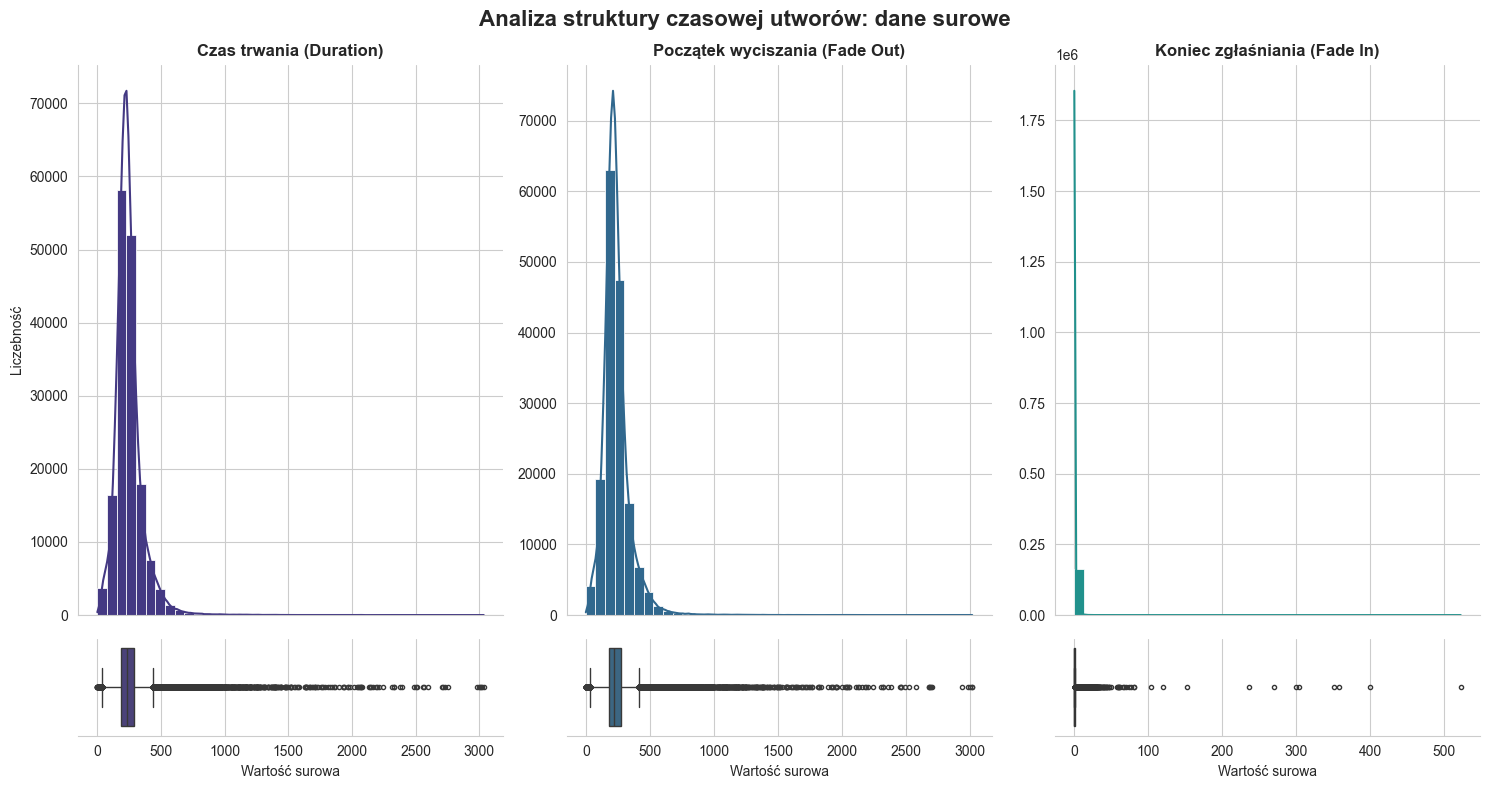

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_raw = ['duration', 'start_of_fade_out', 'end_of_fade_in']
titles = ['Czas trwania (Duration)', 'Początek wyciszania (Fade Out)', 'Koniec zgłaśniania (Fade In)']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex='col', 
                         gridspec_kw={"height_ratios": (.85, .15)})

for i, col in enumerate(cols_raw):
    sns.histplot(data=df_copy, x=col, kde=True, ax=axes[0, i], 
                 color=viridis_colors[i], bins=40, alpha=1.0)
    sns.despine(ax=axes[0, i])
    axes[0, i].set_title(titles[i], fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('Liczebność') if i == 0 else axes[0, i].set_ylabel('')

    sns.boxplot(data=df_copy, x=col, ax=axes[1, i], 
                color=viridis_colors[i], orient='h', fliersize=3) # fliersize zmniejsza kropki outlierów
    sns.despine(ax=axes[1, i], left=True) # usuwamy lewą oś z boxplota
    axes[1, i].set_yticks([]) # usuwamy podpisy osi Y dla boxplota
    axes[1, i].set_xlabel('Wartość surowa')

plt.suptitle('Analiza struktury czasowej utworów: dane surowe', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

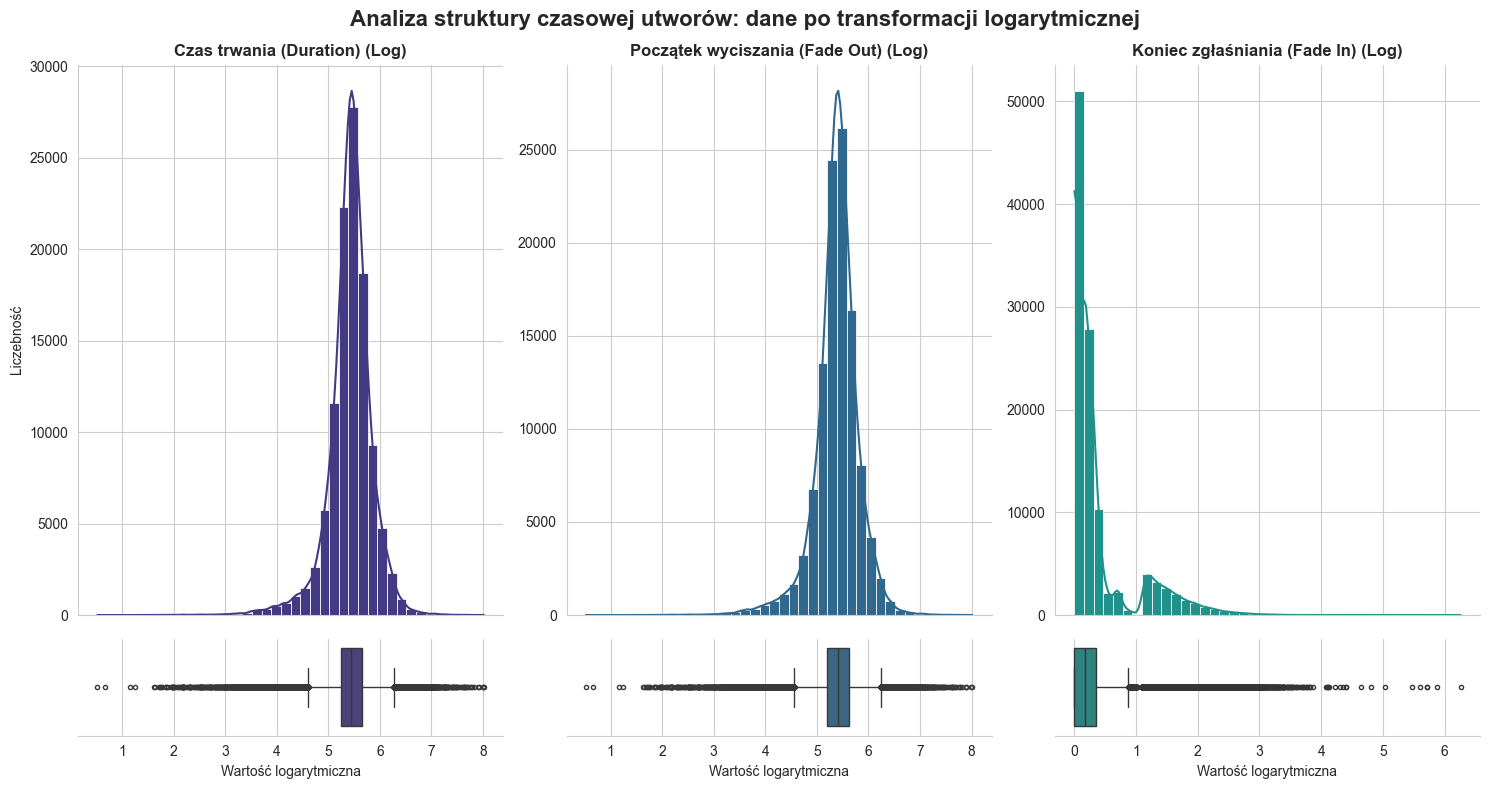

In [ ]:
cols_log = ['duration_log', 'start_of_fade_out_log', 'end_of_fade_in_log']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex='col', 
                         gridspec_kw={"height_ratios": (.85, .15)})

for i, col in enumerate(cols_log):
    sns.histplot(data=df, x=col, kde=True, ax=axes[0, i], 
                 color=viridis_colors[i], bins=40, alpha=1.0)
    sns.despine(ax=axes[0, i])
    axes[0, i].set_title(titles[i] + ' (Log)', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('Liczebność') if i == 0 else axes[0, i].set_ylabel('')

    sns.boxplot(data=df, x=col, ax=axes[1, i], 
                color=viridis_colors[i], orient='h', fliersize=3)
    sns.despine(ax=axes[1, i], left=True)
    axes[1, i].set_yticks([])
    axes[1, i].set_xlabel('Wartość logarytmiczna')

plt.suptitle('Analiza struktury czasowej utworów: dane po transformacji logarytmicznej', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

In [124]:
df['has_fade_in'] = (df['end_of_fade_in_log'] > 0).astype(int)
df.sample()

,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,song_age,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,duration_log,start_of_fade_out_log,end_of_fade_in_log,has_fade_in,play_count_log,has_fade_out
147762,-7.975,1,86.492,0.614075,0.392492,AROK2PM1187B9AC021,The Rippingtons,Life In The Tropics,SOSITTW12AB017CE94,Island Aphrodisiac,2000,19,5.84915,6.193717,37.928572,1.08998,1,1,1,1,0,0,0,1,0,0,11,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,5.64477,5.593845,0.300105,1,2.995732,1


C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1869494258.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='has_fade_in', data=df, palette='viridis')


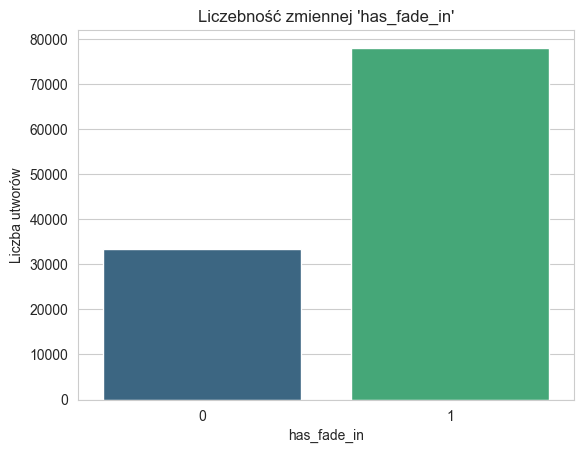

In [125]:
plt.figure()
sns.countplot(x='has_fade_in', data=df, palette='viridis')
plt.title('Liczebność zmiennej \'has_fade_in\'')
plt.ylabel('Liczba utworów')
plt.show()

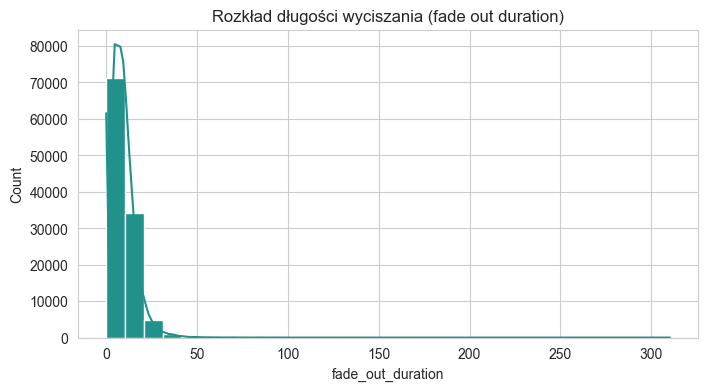

In [126]:
df['fade_out_duration'] = df_copy['duration'] - df_copy['start_of_fade_out']

plt.figure(figsize=(8, 4))
sns.histplot(df['fade_out_duration'], bins=30, kde=True, color=color_viridis, alpha=1)
plt.title('Rozkład długości wyciszania (fade out duration)')
plt.show()

In [127]:
df['has_fade_out'] = (df['fade_out_duration'] > 1.0).astype(int)
df.sample()

,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,song_age,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,duration_log,start_of_fade_out_log,end_of_fade_in_log,has_fade_in,play_count_log,has_fade_out,fade_out_duration
99599,-16.59,1,147.739,0.670114,0.543064,AR4R7QA1187B9AF851,Cirque du Soleil,Journey of Man - Soundtrack Album,SOBTXOA12A8C135FE5,Youth,2000,265,8.853677,1.921288,38.855398,0.990999,1,0,0,1,0,0,0,0,0,1,11,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,5.675065,5.657459,1.251619,1,5.583496,1,5.0873


C:\Users\48726\AppData\Local\Temp\ipykernel_39132\1932334645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='has_fade_out', data=df, palette='viridis')


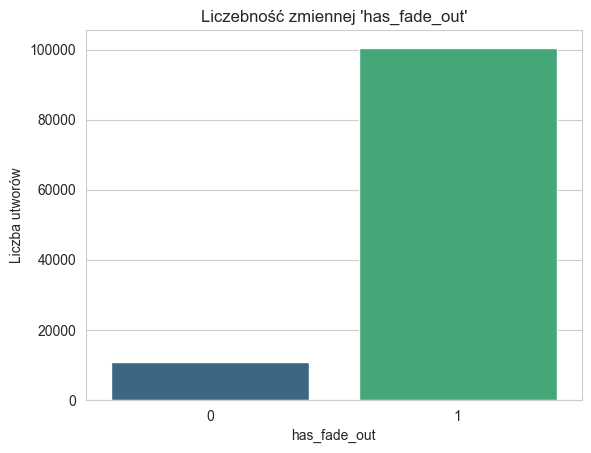

In [128]:
plt.figure()
sns.countplot(x='has_fade_out', data=df, palette='viridis')
plt.title('Liczebność zmiennej \'has_fade_out\'')
plt.ylabel('Liczba utworów')
plt.show()

C:\Users\48726\AppData\Local\Temp\ipykernel_39132\2573989885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='has_fade_in', data=df, palette='viridis', ax=axes[0])
C:\Users\48726\AppData\Local\Temp\ipykernel_39132\2573989885.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Brak', 'Obecny']) # Zamiana 0/1 na słowa
C:\Users\48726\AppData\Local\Temp\ipykernel_39132\2573989885.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='has_fade_out', data=df, palette='viridis', ax=axes[1])
C:\Users\48726\AppData\Local\Temp\ipykernel_39132\2573989885.py:19: UserWarning: set_ti

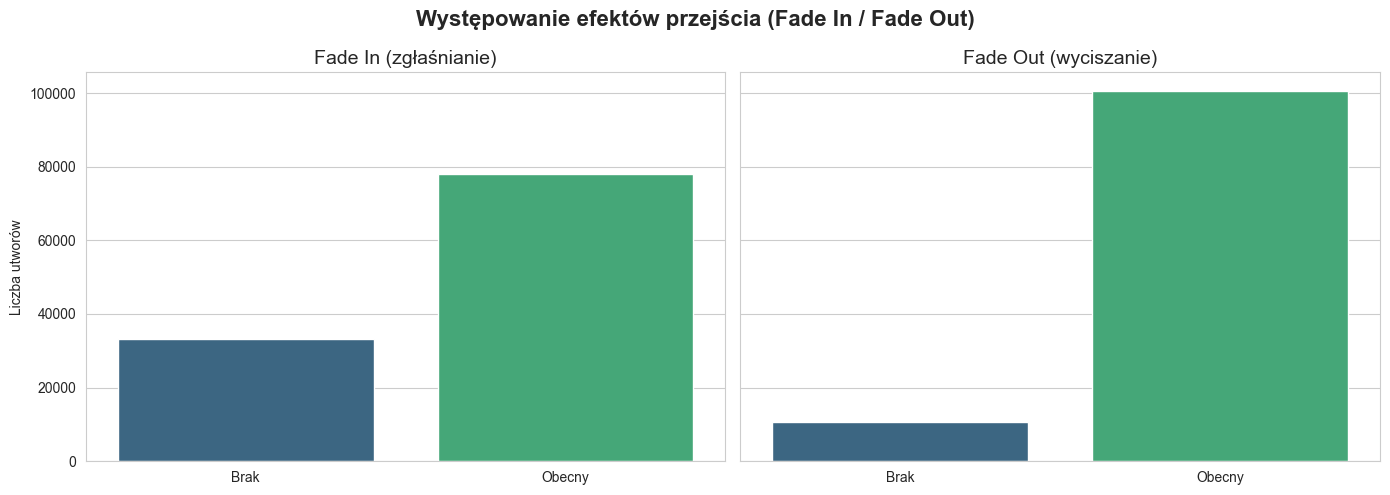

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True) # sharey=True ułatwia porównanie skali

sns.countplot(x='has_fade_in', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Fade In (zgłaśnianie)', fontsize=14)
axes[0].set_xlabel('')
axes[0].set_ylabel('Liczba utworów')
axes[0].set_xticklabels(['Brak', 'Obecny']) # zamiana 0/1 na słowa

sns.countplot(x='has_fade_out', data=df, palette='viridis', ax=axes[1])
axes[1].set_title('Fade Out (wyciszanie)', fontsize=14)
axes[1].set_xlabel('')
axes[1].set_ylabel('') # usuwamy label Y, bo jest wspólny (sharey)
axes[1].set_xticklabels(['Brak', 'Obecny'])

plt.suptitle('Występowanie efektów przejścia (Fade In / Fade Out)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##### Grupa 3: timbre_mean + timre_var + pitch_std 

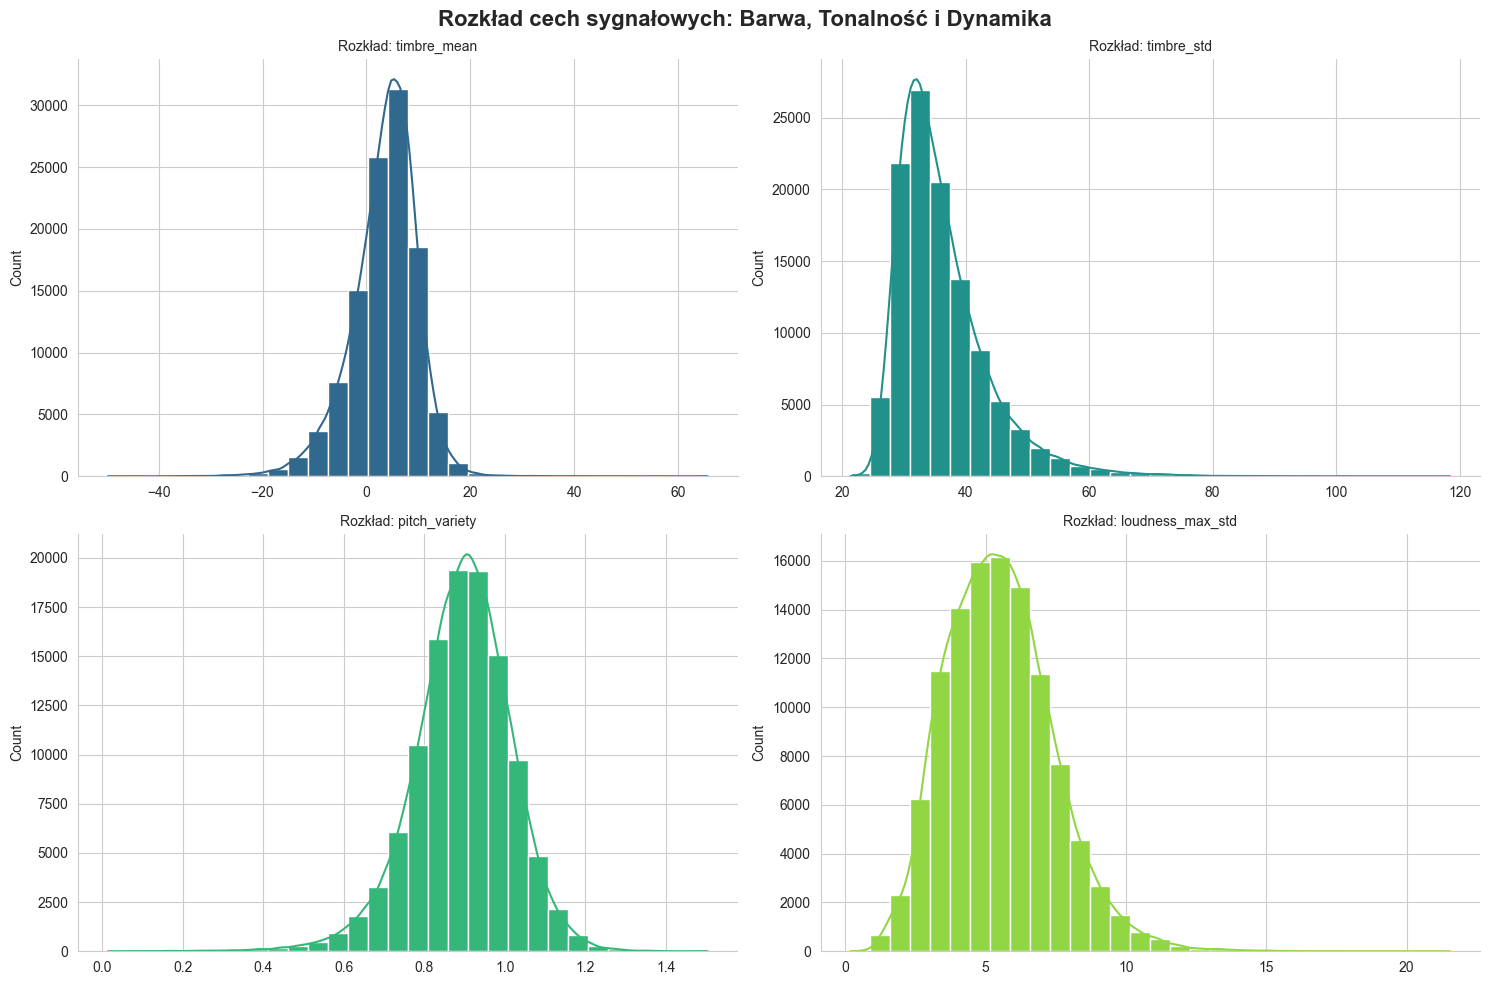

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['timbre_mean', 'timbre_std', 'pitch_variety', 'loudness_max_std']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(data=df, bins=30, x=col, kde=True, ax=axes[i], color=viridis_colors[i+1], alpha=1.0)
    sns.despine(ax=axes[i])
    
    axes[i].set_title(f'Rozkład: {col}', fontsize=10)
    axes[i].set_xlabel('') # Często opis osi X jest zbędny, jeśli tytuł mówi co to

plt.suptitle('Rozkład cech sygnałowych: Barwa, Tonalność i Dynamika', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

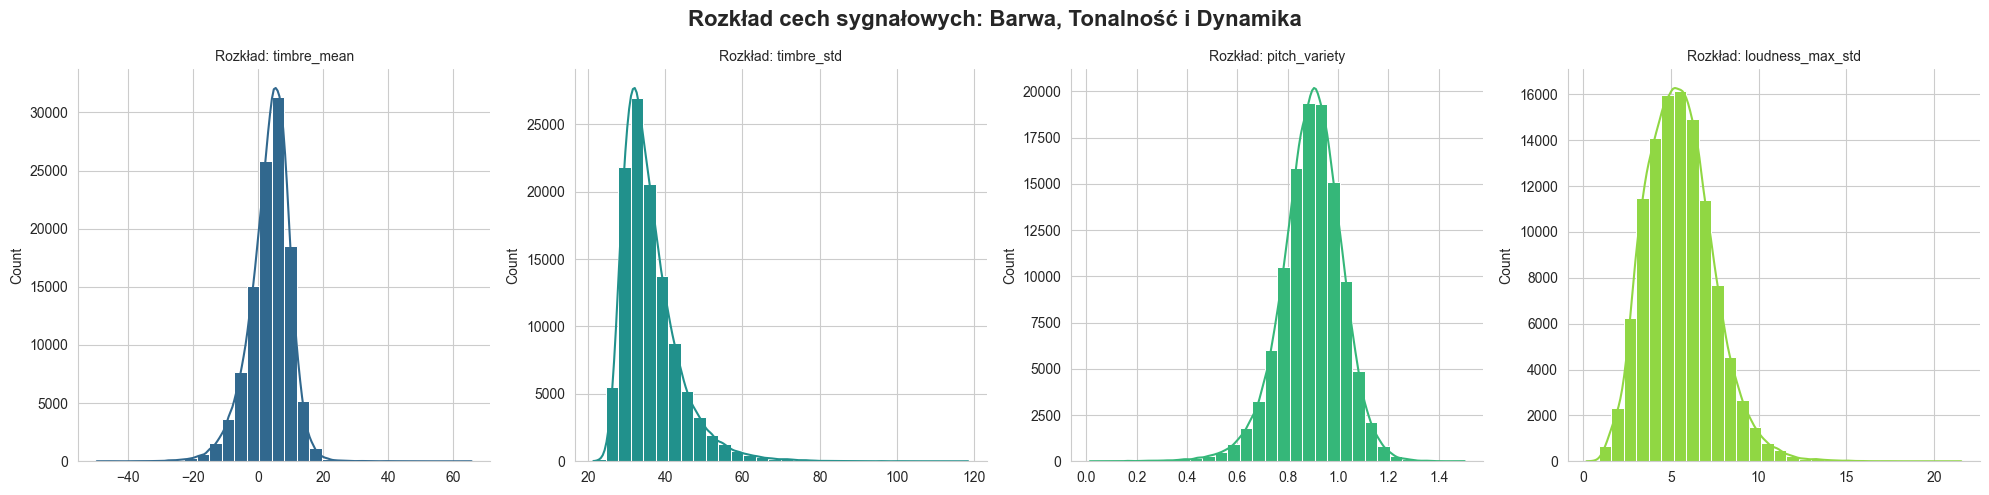

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['timbre_mean', 'timbre_std', 'pitch_variety', 'loudness_max_std']

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(data=df, bins=30, x=col, kde=True, ax=axes[i], color=viridis_colors[i+1], alpha=1.0)
    sns.despine(ax=axes[i])
    
    axes[i].set_title(f'Rozkład: {col}', fontsize=10)
    axes[i].set_xlabel('') # Często opis osi X jest zbędny, jeśli tytuł mówi co to

plt.suptitle('Rozkład cech sygnałowych: Barwa, Tonalność i Dynamika', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##### Grupa 4: loudness + tempo

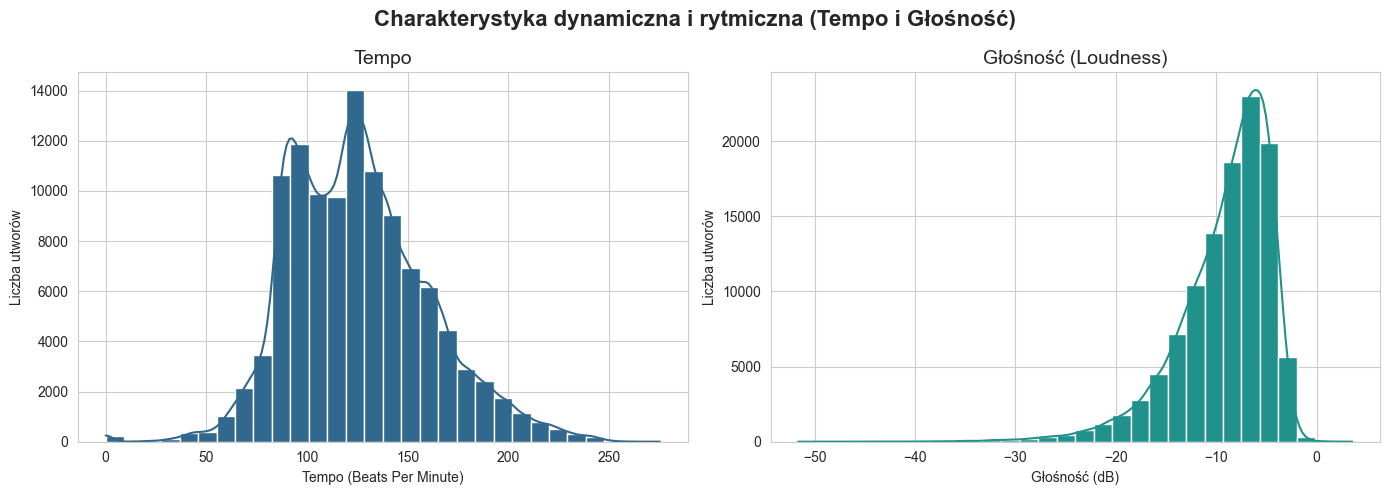

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['tempo'], bins=30, kde=True, color=viridis_colors[1], ax=axes[0], alpha=1)
axes[0].set_title('Tempo', fontsize=14)
axes[0].set_xlabel('Tempo (Beats Per Minute)')
axes[0].set_ylabel('Liczba utworów')

sns.histplot(df['loudness'], bins=30, kde=True, color=viridis_colors[2], ax=axes[1], alpha=1)
axes[1].set_title('Głośność (Loudness)', fontsize=14)
axes[1].set_xlabel('Głośność (dB)')
axes[1].set_ylabel('Liczba utworów')

plt.suptitle('Charakterystyka dynamiczna i rytmiczna (Tempo i Głośność)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##### Zmienna celu - play_count

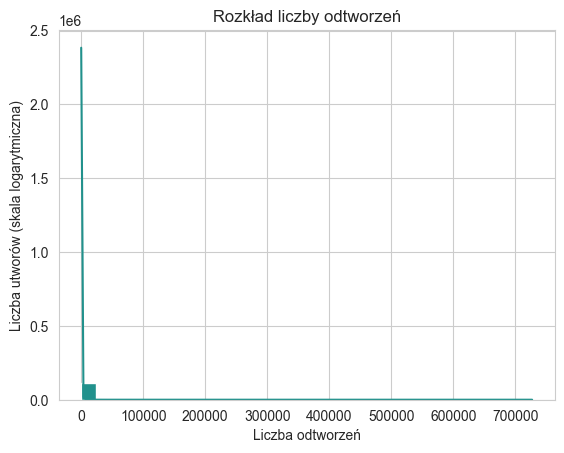

In [72]:
# show the distribution of final df numeric play counts
sns.histplot(df['play_count'].dropna(), bins=30, log_scale=False, color=color_viridis, kde=True, alpha=1)
plt.xlabel('Liczba odtworzeń')
#plt.xscale('log')
plt.ylabel('Liczba utworów (skala logarytmiczna)')
plt.title('Rozkład liczby odtworzeń')
plt.show()

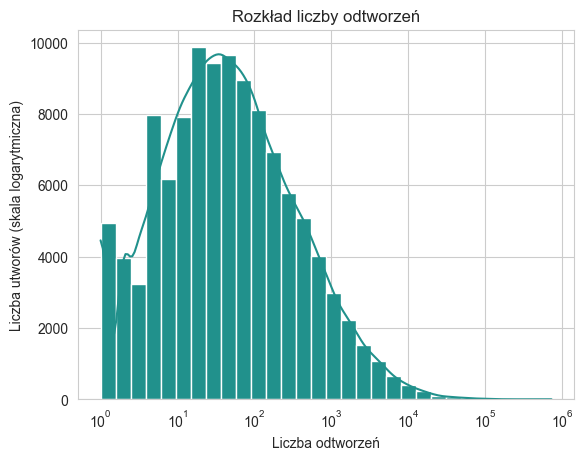

In [76]:
# show the distribution of final df numeric play counts
sns.histplot(df['play_count'].dropna(), bins=30, log_scale=True, color=color_viridis, kde=True, alpha=1)
plt.xlabel('Liczba odtworzeń')
#plt.xscale('log')
plt.ylabel('Liczba utworów (skala logarytmiczna)')
plt.title('Rozkład liczby odtworzeń')
plt.show()

Aby wydobyć jakiekolwiek informacje ze zmiennej 'play_count', musimy ją najpierw zlogarytmować.

In [74]:
df[f'play_count_log'] = np.log1p(df['play_count'].clip(lower=0))
#df = df.drop(columns=['play_count'])
df.sample()

,key_confidence,loudness,mode,mode_confidence,tempo,time_signature_confidence,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,song_age,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,duration_log,start_of_fade_out_log,end_of_fade_in_log,has_fade_in,play_count_log
29345,0,-7.965,1,0.298,149.963,0.212,0.578582,0.319909,ARHONLU12086C156E3,La Caravane Passe,Velkom Pléchti!,SOAHLFF12AAA15E940,Belly Tanz,2008,7,4.989874,7.175371,34.153871,0.936053,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,5.296881,5.275806,1.1207,1,2.079442


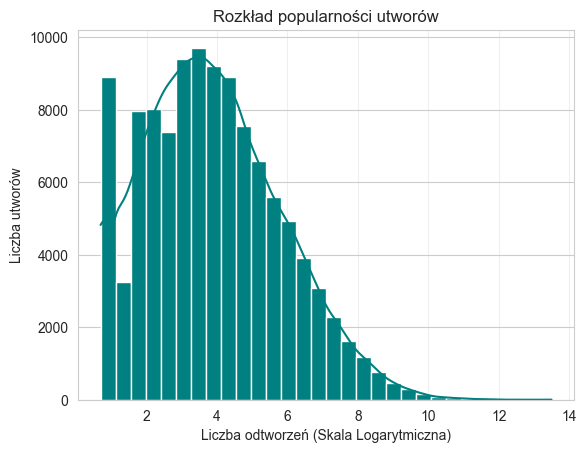

In [78]:
sns.histplot(df['play_count_log'], bins=30, kde=True, color='teal', alpha=1)

# podmiana osi x na "ładne" liczby
# human_ticks = [1, 10, 100, 1000, 10000, 100000, 500000]
# log_ticks = np.log1p(human_ticks)
# plt.xticks(log_ticks, human_ticks)

plt.xlabel('Liczba odtworzeń (Skala Logarytmiczna)')
plt.ylabel('Liczba utworów')
plt.title('Rozkład popularności utworów')
plt.grid(axis='x', alpha=0.3)

plt.show()

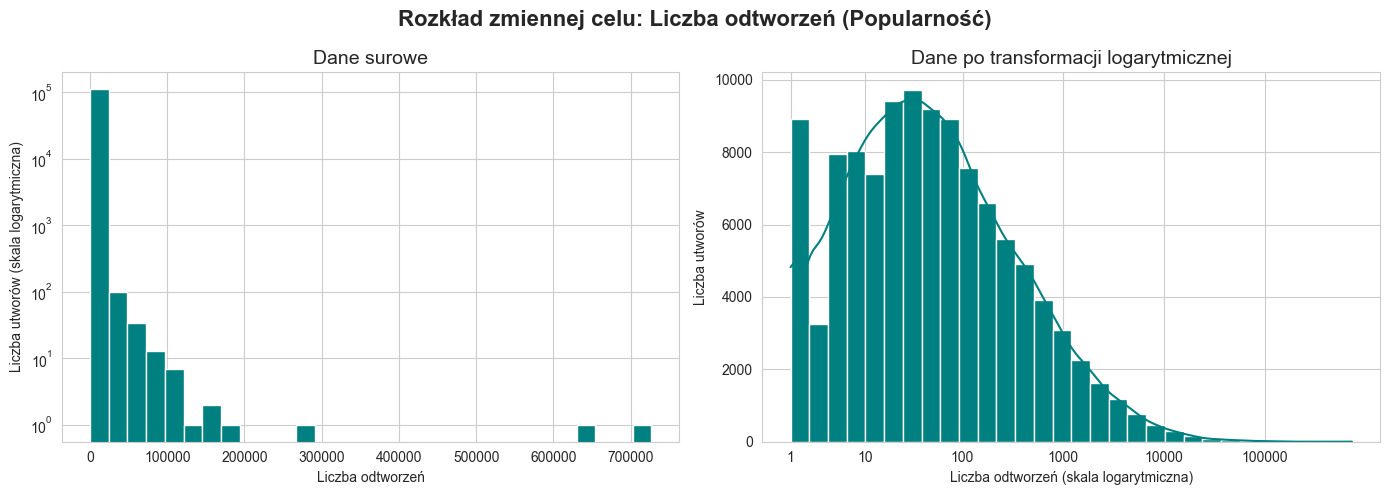

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['play_count'].dropna(), bins=30, color='teal', kde=False, ax=axes[0], alpha=1)
axes[0].set_title('Dane surowe', fontsize=14)
axes[0].set_xlabel('Liczba odtworzeń')
axes[0].set_ylabel('Liczba utworów (skala logarytmiczna)')
axes[0].set_yscale('log') # Skala log na Y pomaga zobaczyć te słupki, które ledwo widać


sns.histplot(df['play_count_log'], bins=30, kde=True, color='teal', ax=axes[1], alpha=1)
axes[1].set_title('Dane po transformacji logarytmicznej', fontsize=14)
axes[1].set_xlabel('Liczba odtworzeń (skala logarytmiczna)')
axes[1].set_ylabel('Liczba utworów')

human_ticks = [1, 10, 100, 1000, 10000, 100000] 
log_ticks = np.log1p(human_ticks) # przeliczamy na skalę logarytmu
axes[1].set_xticks(log_ticks)
axes[1].set_xticklabels(human_ticks) # podpisujemy "po ludzku"


plt.suptitle('Rozkład zmiennej celu: Liczba odtworzeń (Popularność)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### usunięcie kolumn 'confidence'

Z datasetu usuwamy zmienne typu 'mode_confidence', ponieważ nie niosą żadnej informacji muzycznej; stanowią jedynie 'technikalia'.

In [110]:
# drop columns with 'confidence' in their names
cols_to_drop = [col for col in df.columns if 'confidence' in col]
df = df.drop(columns=cols_to_drop)
df.sample()

,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,song_age,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,duration_log,start_of_fade_out_log,end_of_fade_in_log,has_fade_in,play_count_log,fade_out_duration,has_fade_out
123834,-3.585,1,90.743,0.498036,0.348884,ARKLG2Q1187B9A533B,The Sylvers,Classic Masters,SOKXTFX12AB0186D29,High School Dance,1995,13,6.641633,19.084643,38.224408,0.640637,1,1,1,1,0,0,0,1,0,0,16,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,5.435985,5.402448,0.212689,1,2.639057,7.56973,1


In [138]:
df = df.drop(columns=['fade_out_duration'])
df.sample()

,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,song_age,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,duration_log,start_of_fade_out_log,end_of_fade_in_log,has_fade_in,play_count_log,has_fade_out
55677,-4.556,1,123.947,0.473624,0.413153,ARMYQX01187FB562BD,Die Roten Rosen,Wir warten auf's Christkind,SOWIXQZ12A8AE478D1,Weihnachtsmann vom Dach,1998,592,8.661311,4.096755,31.353165,0.898156,1,1,0,1,1,1,0,0,1,0,13,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,5.492623,5.444221,0.19721,1,6.385194,1


In [139]:
missing_data = df.isna().sum()
print(missing_data[missing_data > 0])

Series([], dtype: int64)


In [146]:
df = df.drop(columns=['artist_id'])

In [147]:
df.shape

(111341, 55)

In [149]:
cols_order = ['song_id', 'title', 'artist_name', 'release', 'year', 'play_count', 'play_count_log', 'duration_log', 'end_of_fade_in_log', 'start_of_fade_out_log', 'loudness', 'mode', 'tempo', 'artist_familiarity', 'artist_hotttnesss', 'loudness_max_std', 'timbre_mean', 'timbre_std', 'pitch_variety', 'song_age', 'is_rock', 'is_pop', 'is_jazz', 'is_electronic', 'is_hiphop', 'is_rap', 'is_metal', 'is_soul', 'is_punk', 'is_classical', 'is_older_than_50s', 'is_50s', 'is_60s', 'is_70s', 'is_80s', 'is_90s', 'is_00s', 'key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#', 'ts_1', 'ts_3', 'ts_4', 'ts_5', 'ts_7', 'has_fade_in', 'has_fade_out']
len(cols_order)
df = df[cols_order]

In [150]:
df.sample()

,song_id,title,artist_name,release,year,play_count,play_count_log,duration_log,end_of_fade_in_log,start_of_fade_out_log,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,loudness_max_std,timbre_mean,timbre_std,pitch_variety,song_age,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,has_fade_in,has_fade_out
157650,SOOJGKV12A58A76E79,My Father's Life's Work,Harvey Milk,My Love Is Higher Than Your Assessment Of What...,1996,12,2.564949,6.390838,2.211894,6.355707,-10.387,1,122.177,0.616147,0.428893,15.548709,-4.510891,46.573164,0.876379,15,1,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1


In [151]:
df.to_csv('../../DATA/processed/new_final_df.csv', index=False)

### Topowe utwory

In [152]:
# show songs with highest play counts
top_songs = df.sort_values(by='play_count_log', ascending=False).head(10).copy()
top_songs['play_count'] = np.expm1(top_songs['play_count_log'])
top_songs[['title', 'artist_name', 'play_count']]

,title,artist_name,play_count
2494,You're The One,Dwight Yoakam,726885.0
101621,Undo,Björk,648239.0
130939,Invalid,Tub Ring,268353.0
157668,Marry Me,Train,174080.0
142416,Make Love To Your Mind,Bill Withers,146978.0
120579,Use Somebody,Kings Of Leon,145725.0
47487,Pursuit Of Happiness (nightmare),Kid Cudi / MGMT / Ratatat,124162.0
66667,Clocks,Coldplay,114362.0
140516,Somebody To Love,Justin Bieber,110757.0
123587,Yellow,Coldplay,109566.0


## Feature Selection

In [154]:
fs_df = pd.read_csv('../../DATA/processed/new_final_df.csv')
fs_df = fs_df.drop(columns=['play_count'])
fs_df.sample()

,song_id,title,artist_name,release,year,play_count_log,duration_log,end_of_fade_in_log,start_of_fade_out_log,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,loudness_max_std,timbre_mean,timbre_std,pitch_variety,song_age,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,is_older_than_50s,is_50s,is_60s,is_70s,is_80s,is_90s,is_00s,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,has_fade_in,has_fade_out
27628,SODMIKF12AB01904E0,Volcano (Album),Jupiter One,Sunshower,2009,3.970292,5.459271,1.14486,5.414512,-5.716,1,187.856,0.606169,0.374449,6.883502,4.13715,32.949464,0.965773,2,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,1


### Mapa korelacji

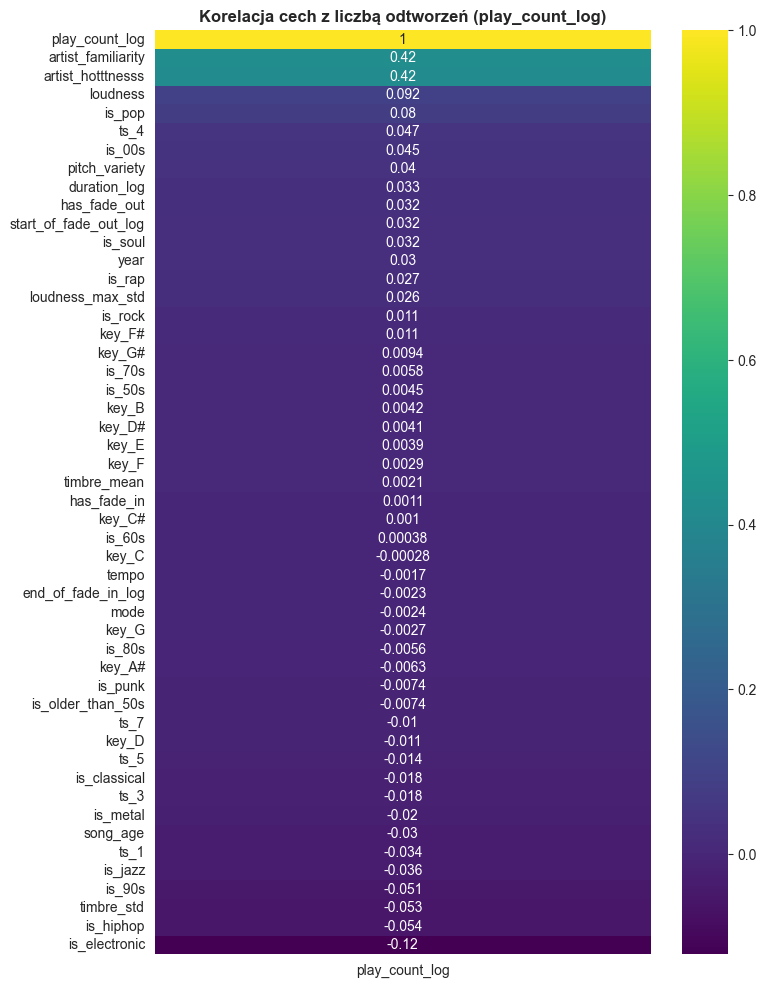

In [ ]:
plt.figure(figsize=(8, 12)) 
df_corr = fs_df.copy().drop(columns=['song_id', 'title', 'artist_name', 'release'])
heatmap_data = df_corr.corr()[['play_count_log']].sort_values(by='play_count_log', ascending=False)

sns.heatmap(heatmap_data, annot=True, cmap='viridis')

plt.title("Korelacja cech z liczbą odtworzeń (play_count_log)", fontweight='bold')
plt.show()

Text(0.5, 1.0, 'Macierz korelacji cech')

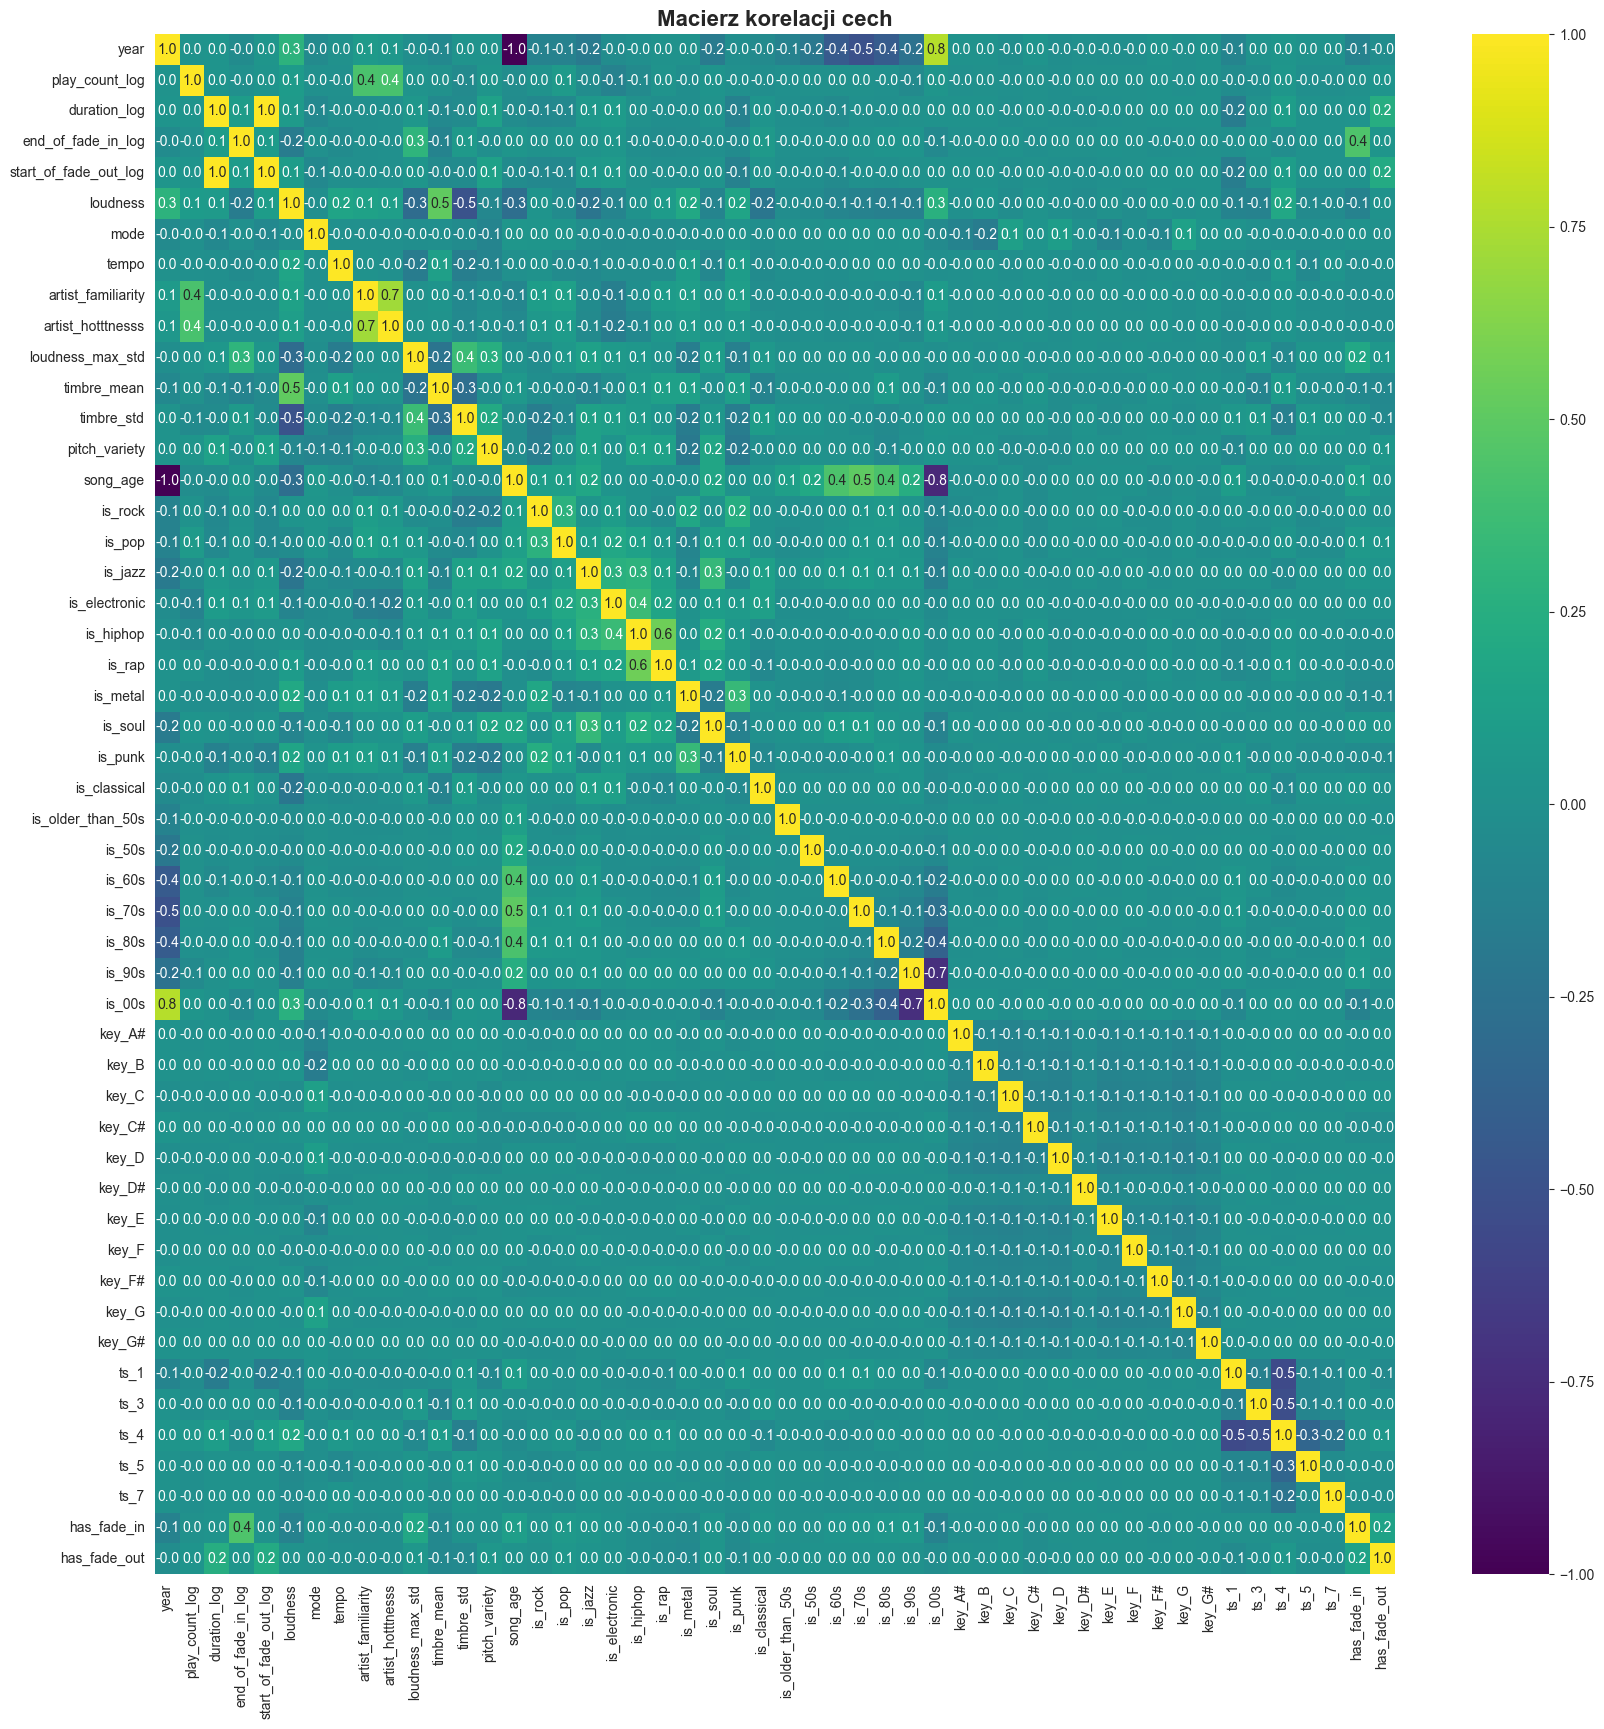

In [200]:
# plot correlation heastmap
plt.figure(figsize=(20, 20))
sns.heatmap(df_corr.corr(), annot=True, fmt=".1f", cmap='viridis')
plt.title('Macierz korelacji cech', fontweight='bold', fontsize=16)

Możemy zauważyć całkowitą korelację (-1.0) cech 'year' i 'song_age', ponieważ matematycznie niosą za sobą dokładnie taką samą informację. 

Dla modeli opartych na drzewach decyzyjnych (las losowy i xgb) bez problemu możemy użyć zmiennej 'year' - modele te są odporne na brak skalowania, więc nie potrzebne im ani wiek utworu ani flag utworów (np. is_90). Poradzą sobie one również ze względną nieliniowością 'artist_familiarity' i 'artist_hotttnesss' (chociaż tutaj jedną z cech lepiej byłoby usunąć).

Pozostałe modele (regresja logistyczna - liniowy; svm - odległościowy; sieci) potrzebują gładkich i PRZESKALOWANYCH danych. Jeśli użyjmey skalera, bez problemu można usunąć zmienne 'song_age' i flagi dekad. Należy unikać jednak cech o wysokiej korelacji -> usunąć 'artist_familiarity' lub 'artist_hotttnesss'.

Żeby nie tworzyć osobnych zbiorów danych, możemy usunąć pochodne kolumny 'year' oraz przeskalować dane. Modelom drzewiastym to nie zaszkodzi, a unikniemy w ten sposób dodatkowej pracy. W przypadku kolumn 'artist_familiarity' i 'artist_hotttnesss' odrzucamy *familiarity*. Bardziej intereuje nas, czy artysta jest (był w 2011) na topie, niż to, czy jest rozpoznawalny (np. byłe legendy, których nikt już nie słucha). Dla modeli drzewiastych możnaby zostawić obie cechy (bo wysokie familiarity + niskie hotttnesss = "artysta przebrzmiały / has-been" (nikt nie słucha), a niskie familiarity + wysokie hotttnesss = "wschodząca gwiazda / viral" (dużo odtworzeń)). Wstępnie decydujemy się jednak na *JEDEN* uniwersalny dataset.



Całkowita korelacja występuje również między cehami 'start_of_fade_out' oraz 'duration'. Może to oznaczać, że większość utworów kończy się bez fade_outu. Bardziej intuicyjną, a jednocześnie bardziej 'surową', informacją jest 'duration'. To ją zostawimy w finalnym datasecie.

**[NOWE]** W zestawie danych zostawiamy obie cechy dotyczące artysty, ponieważ mimo wysokiej korelacji niosią za sobą dwie różne informacje (to jak porównywamie The Beatles z Taylor Swift). Nie zważamy na to, że modele niedrzewiaste mogą sobie z takim podejściem nie poradzić.

In [160]:
# Sprawdź korelację z celem
print(df[['artist_familiarity', 'artist_hotttnesss', 'play_count_log']].corr()['play_count_log'])

artist_familiarity    0.423372
artist_hotttnesss     0.416240
play_count_log        1.000000
Name: play_count_log, dtype: float64


In [162]:
modeling_df = df.drop(columns=['start_of_fade_out_log', 'song_age', 'is_older_than_50s', 'is_50s', 'is_60s', 'is_70s', 'is_80s', 'is_90s', 'is_00s'])
modeling_df.sample()

,song_id,title,artist_name,release,year,play_count,play_count_log,duration_log,end_of_fade_in_log,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,has_fade_in,has_fade_out
142225,SOAKPQI12A6310E007,In Your Car,Kenickie,At The Club,1996,81,4.406719,5.428445,0.72222,-7.584,1,177.457,0.563516,0.371137,3.125418,7.293913,31.816212,0.97012,1,1,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,1


In [ ]:
cols_order = ['song_id', 'title', 'artist_name', 'release', 'year', 'play_count_log', 'duration', 'end_of_fade_in_log', 'loudness', 'mode', 'tempo', 'artist_hotttnesss', 'loudness_max_std', 'timbre_mean', 'timbre_std', 'pitch_variety', 'artist_avg_popularity_log', 'is_rock', 'is_pop', 'is_jazz', 'is_electronic', 'is_hiphop', 'is_rap', 'is_metal', 'is_soul', 'is_punk', 'is_classical', 'key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#', 'ts_1', 'ts_3', 'ts_4', 'ts_5', 'ts_7']
modeling_df = modeling_df[cols_order]
modeling_df.sample()

,song_id,title,artist_name,release,year,play_count_log,duration,end_of_fade_in_log,loudness,mode,tempo,artist_hotttnesss,loudness_max_std,timbre_mean,timbre_std,pitch_variety,artist_avg_popularity_log,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7
5057,SONVVZT12AC4688880,Delicate December,Erin McKeown,We Will Become Like Birds,2005,2.944439,185.20771,0.091667,-13.107,1,200.38,0.455379,6.08266,-12.659305,52.079066,0.883482,6.546785,1,1,1,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0


Text(0.5, 1.0, 'Macierz korelacji cech - dane do modelowania')

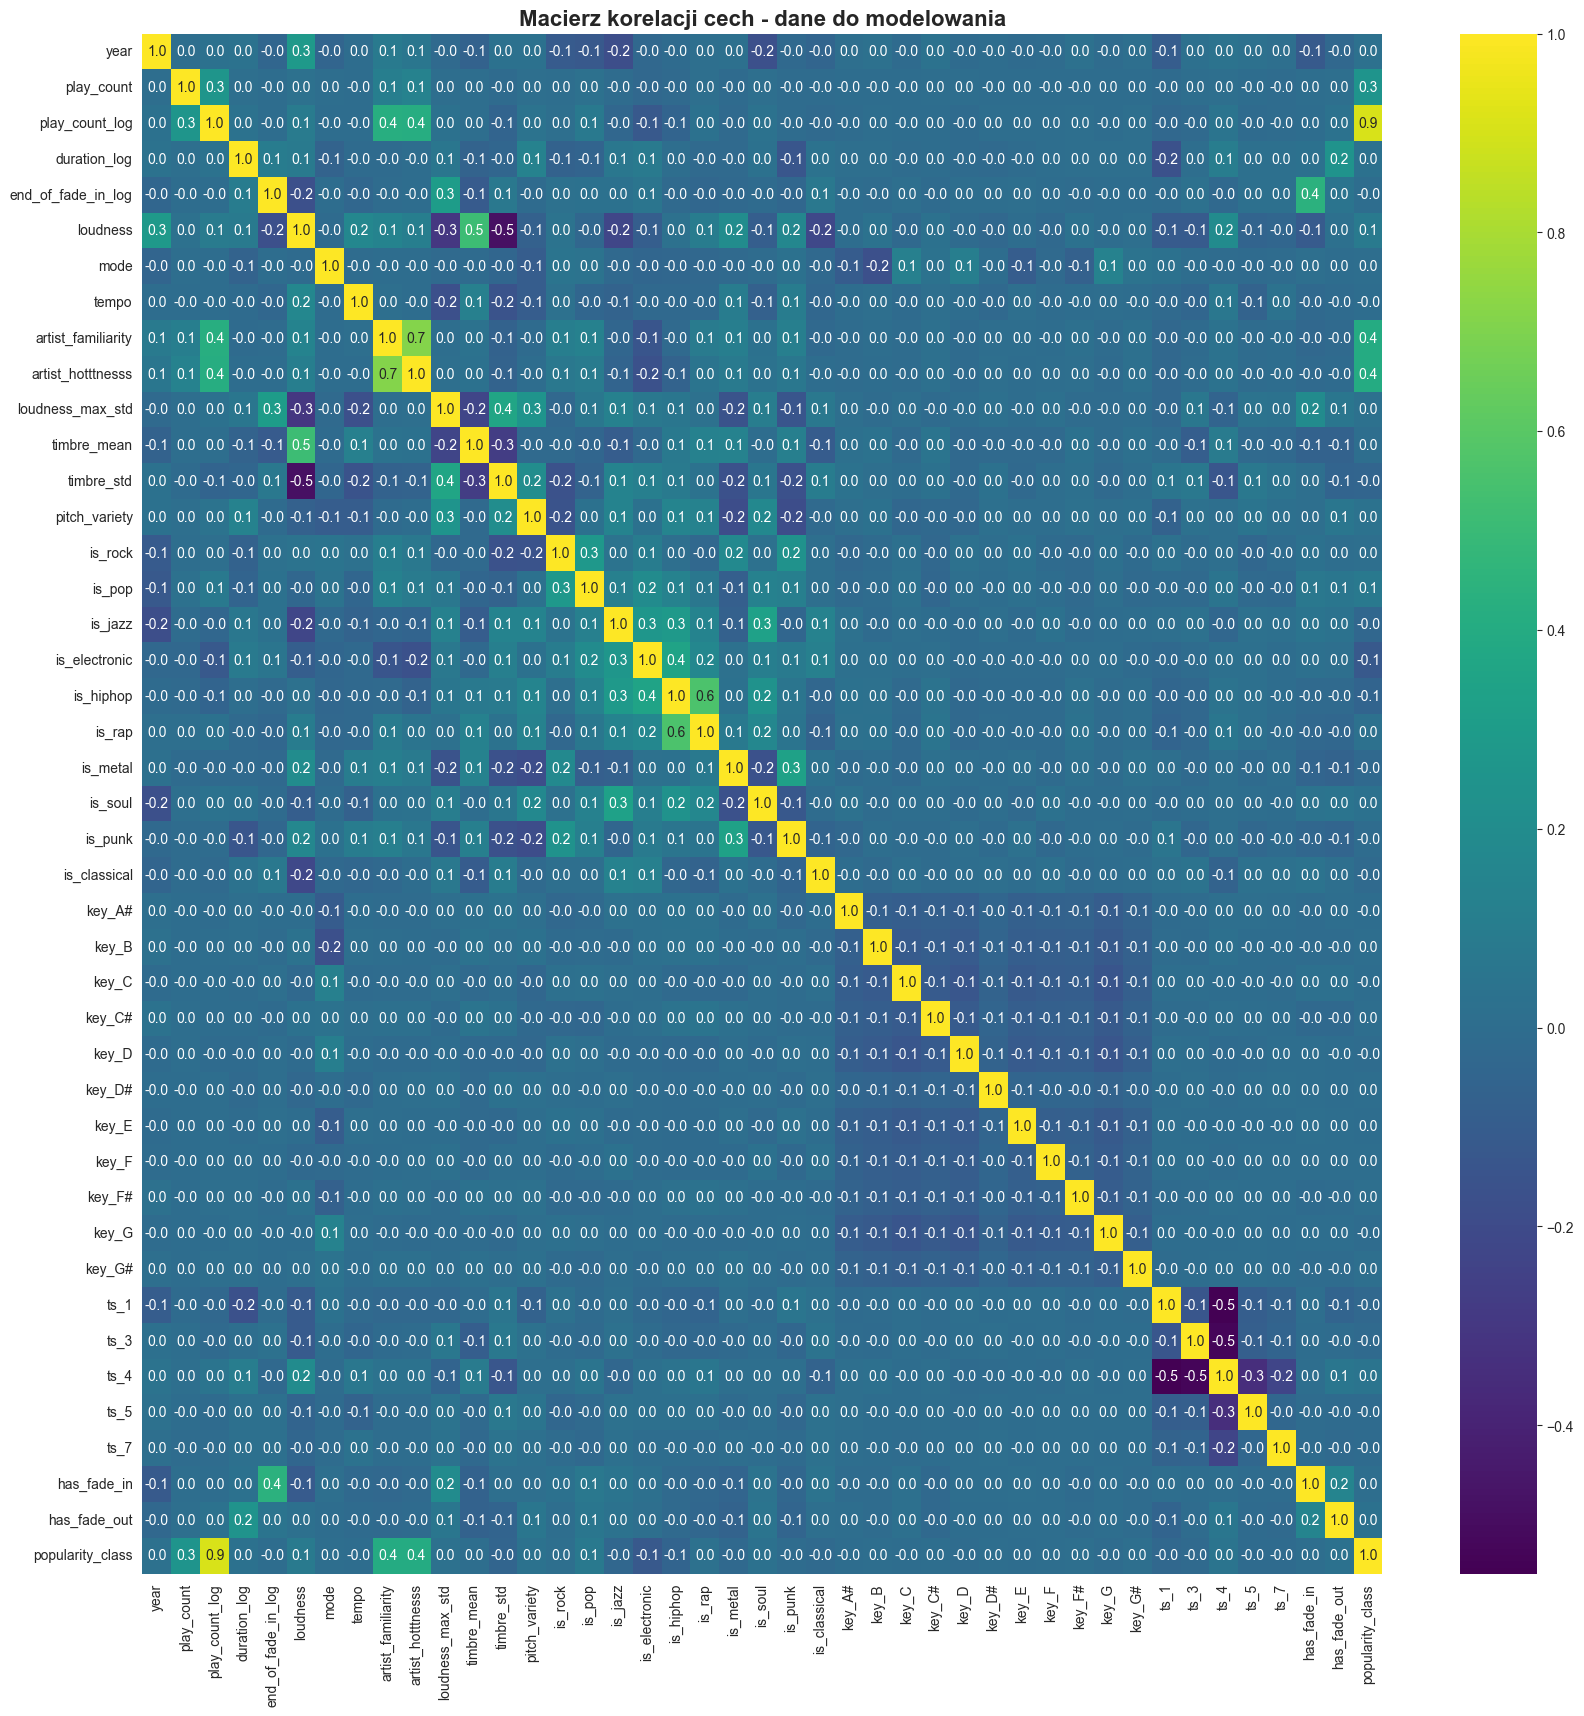

In [201]:
df_corr = modeling_df.drop(columns=['song_id', 'title', 'artist_name', 'release'])
plt.figure(figsize=(20, 20))
sns.heatmap(df_corr.corr(), annot=True, fmt=".1f", cmap='viridis')
plt.title('Macierz korelacji cech - dane do modelowania', fontsize=16, fontweight='bold')

Teraz, w datasecie występują jednie niezależne (niskoskorelowane ze sobą zmienne). Można bez problemu przeprowadzać na nich modelowaneie. 

In [164]:
modeling_df.to_csv('../../DATA/processed/new_final_modeling_df.csv', index=False)

## Dyskretyzacja zmiennej objaśnianej

0. Obscure (Niszowy / Nieznany) 
1. Underground (Mało znany)
2. Moderate (Średniak / Zwykły)
3. Popular (Hit)
4. Superstar (Megahit)

In [165]:
modeling_df.sample()

,song_id,title,artist_name,release,year,play_count,play_count_log,duration_log,end_of_fade_in_log,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,has_fade_in,has_fade_out
106763,SOITYUU12A8C14119A,Cruisin',Pacha Massive,All Good Things,2007,87,4.477337,5.537419,0.274597,-8.18,0,93.996,0.590819,0.420945,4.888817,0.606379,33.945902,0.823164,0,0,1,1,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1


Równy podział

In [ ]:
labels = [0, 1, 2, 3, 4] 
# tworzymy nową kolumnę 'popularity_class'
# q=5 oznacza podział na 5 równych części (po 20% piosenek w każdej)
modeling_df['popularity_class'] = pd.qcut(df['play_count'], q=5, labels=labels)

print("Rozkład kategorii:")
print(modeling_df['popularity_class'].value_counts().sort_index())

Rozkład kategorii:
popularity_class
0    22358
1    22567
2    22129
3    22056
4    22231
Name: count, dtype: int64


In [ ]:
ranges = modeling_df.groupby('popularity_class')['play_count'].agg(['min', 'max'])

labels_map = {0: 'Obscure (nieznany)', 1: 'Underground (niszowy)', 2: 'Regular (przeciętne)', 3: 'Hit', 4: 'Megahit'}
ranges.index = ranges.index.map(labels_map)

print(ranges)

                       min     max
popularity_class                  
Obscure (nieznany)       1       7
Underground (niszowy)    8      24
Regular (przeciętne)    25      69
Hit                     70     256
Megahit                257  726885


C:\Users\48726\AppData\Local\Temp\ipykernel_39132\3620800611.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ranges = modeling_df.groupby('popularity_class')['play_count'].agg(['min', 'max'])


Podział wg logiki (równy podział wyszedł bez sensu)

In [ ]:
# granice: 0 -> 50 -> 500 -> 5000 -> MAX
bins = [0, 50, 500, 5000, np.inf]
labels = [0, 1, 2, 3] 

modeling_df['popularity_class'] = pd.cut(modeling_df['play_count'], bins=bins, labels=labels, right=False)

# sprawdzamy, czy nie ma NaN (np. przez błędy zaokrągleń na krawędziach)
modeling_df['popularity_class'] = modeling_df['popularity_class'].cat.add_categories([-1]).fillna(0).astype(int)
modeling_df.sample()

,song_id,title,artist_name,release,year,play_count,play_count_log,duration_log,end_of_fade_in_log,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,has_fade_in,has_fade_out,popularity_class
59393,SOKTNET12AB01813F5,The serpent's kiss,Symphony X,Paradise Lost,2007,534,6.282267,5.71881,0.182322,-5.214,1,102.016,0.699515,0.536762,3.727864,5.285085,29.662219,0.83755,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,1,2


In [169]:
print("Nowy rozkład klas (według sztywnych progów):")
counts = modeling_df['popularity_class'].value_counts().sort_index()
print(counts)

print("\nProcentowy udział klas:")
print(counts / len(modeling_df) * 100)
class_names = {0: 'Niszowe (<50)', 1: 'Średnie (50-500)', 2: 'Znane (500-5k)', 3: 'Hity (>5k)'}
print("\nLegenda:")
for k, v in class_names.items():
    print(f"Klasa {k}: {v}")

Nowy rozkład klas (według sztywnych progów):
popularity_class
0    60001
1    37166
2    12620
3     1554
Name: count, dtype: int64

Procentowy udział klas:
popularity_class
0    53.889403
1    33.380336
2    11.334549
3     1.395712
Name: count, dtype: float64

Legenda:
Klasa 0: Niszowe (<50)
Klasa 1: Średnie (50-500)
Klasa 2: Znane (500-5k)
Klasa 3: Hity (>5k)


Po dyskretyzacji odpowiedniej dla liczby odtworzeń poszcególnych kategorii otrzymujemy rozkład odpowiedni dla rynku muzycznego (80/20). Mimo niewielkiego udziału procentowego klasy hitów, modele będą w stanie nauczyć się wzorców. Należy jedynie pamiętać o ustawieniu parametru *class_weight='balanced'*.

In [171]:
class_df = modeling_df.copy()
# class_df.drop(columns=['play_count', 'play_count_log'], inplace=True)

cols_order = ['song_id', 'title', 'artist_name', 'release', 'year', 'popularity_class', 'duration_log', 'end_of_fade_in_log', 'loudness', 'mode', 'tempo', 'artist_familiarity', 'artist_hotttnesss', 'loudness_max_std', 'timbre_mean', 'timbre_std', 'pitch_variety', 'is_rock', 'is_pop', 'is_jazz', 'is_electronic', 'is_hiphop', 'is_rap', 'is_metal', 'is_soul', 'is_punk', 'is_classical', 'key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#', 'ts_1', 'ts_3', 'ts_4', 'ts_5', 'ts_7', 'has_fade_in', 'has_fade_out']
class_df = class_df[cols_order]
class_df.sample()


,song_id,title,artist_name,release,year,popularity_class,duration_log,end_of_fade_in_log,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,has_fade_in,has_fade_out
4974,SOKRSCD12AB01822B6,Frenomotor,Tonino Carotone,Ciao Mortali!,2008,0,5.258619,0.0,-6.614,1,123.636,0.551728,0.366292,3.467481,7.397745,33.714474,0.892247,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1


In [172]:
class_df.to_csv('../../DATA/processed/new_final_classification_df.csv', index=False)

In [174]:
reg_df = modeling_df.copy()
reg_df = reg_df.drop(columns=['popularity_class', 'play_count'])
reg_df.sample()

,song_id,title,artist_name,release,year,play_count_log,duration_log,end_of_fade_in_log,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,has_fade_in,has_fade_out
25389,SOPSJAA12A8C13D30D,Bad News,A.R.E. Weapons,A.R.E. Weapons,2003,2.70805,5.273993,0.0,-4.764,0,96.111,0.584058,0.298211,3.035073,7.342994,29.862998,0.85809,1,1,0,1,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1


In [175]:
reg_df.to_csv('../../DATA/processed/new_final_regression_df.csv', index=False)